### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Loading Cleaned Dataset

In [5]:
df_cleaned_transaction_data = pd.read_parquet(r"C:\Users\leest\OneDrive\Data Projects\Amdari Projects\Digital_Transfer_Fraud_Detection_System\Datasets\Artifats\Cleaned_Finlora_Dataset.parquet")

### Setting a Consistent Visualisation Theme

In [20]:
# Set a clean, professional theme
sns.set_theme(
    style="white",
    context="notebook",
    font_scale=1.1
)

# Create a readable label column for is_fraud
df_cleaned_transaction_data["fraud_label"] = df_cleaned_transaction_data["is_fraud"].map({
    0: "Legitimate",
    1: "Fraud"
})

# Consistent color mapping for fraud analysis
fraud_palette = {
    "Legitimate": "#2E75B6",   # blue - calm/normal
    "Fraud": "#C0392B"         # red - alert/risk
}

# General palette for non-fraud-specific categorical plots (channel, currency, etc.)
sns.set_palette(["#2E75B6", "#C0392B", "#59A14F", "#F4A261", "#8E7CC3", "#4C4C4C"])

### 1. The Fraud Landscape - Baseline Understanding
Establishing the scale of the problem before digging into drivers.

In [15]:
# Question 1 - How many customers and transactions are we looking at?

print(f"There are {df_cleaned_transaction_data["customer_id"].nunique()} customers and {df_cleaned_transaction_data["transaction_id"].nunique()} transactions represented in this dataset")

There are 1314 customers and 10940 transactions represented in this dataset


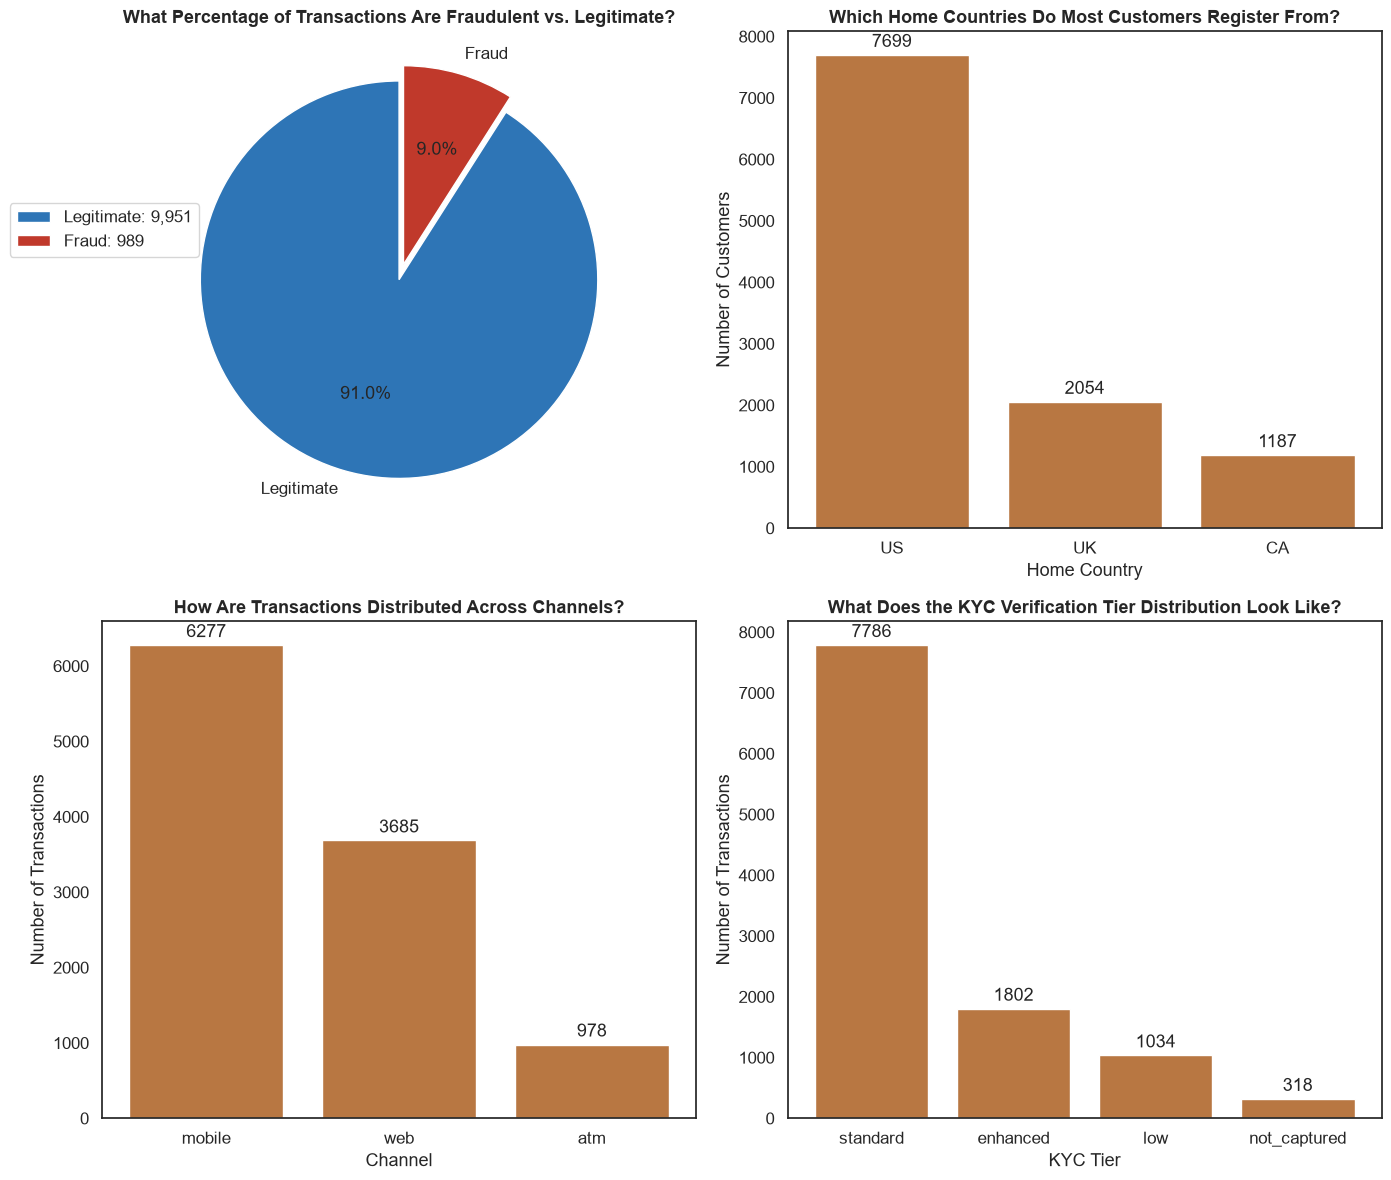

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Q2: What percentage of transactions are fraudulent vs. legitimate?
fraud_counts = df_cleaned_transaction_data["fraud_label"].value_counts()

wedges, texts, autotexts = axes[0].pie(
    fraud_counts,
    labels=fraud_counts.index,
    autopct="%1.1f%%",
    colors=[fraud_palette[label] for label in fraud_counts.index],
    startangle=90,
    explode=[0, 0.08]
)
axes[0].set_title("What Percentage of Transactions Are Fraudulent vs. Legitimate?")
axes[0].legend(
    wedges,
    [f"{label}: {count:,}" for label, count in fraud_counts.items()],
    loc="center left",
    bbox_to_anchor=(-0.3, 0.6)
)

# Q3: Which home countries do most customers register from?
country_counts = df_cleaned_transaction_data["home_country"].value_counts()
bars = axes[1].bar(country_counts.index, country_counts.values, color="#B87742")
axes[1].bar_label(bars, fmt="%d", padding=3)
axes[1].set_title("Which Home Countries Do Most Customers Register From?")
axes[1].set_xlabel("Home Country")
axes[1].set_ylabel("Number of Customers")

# Q4: How are transactions distributed across channels?
channel_counts = df_cleaned_transaction_data["channel"].value_counts()
bars = axes[2].bar(channel_counts.index, channel_counts.values, color="#B87742")
axes[2].bar_label(bars, fmt="%d", padding=3)
axes[2].set_title("How Are Transactions Distributed Across Channels?")
axes[2].set_xlabel("Channel")
axes[2].set_ylabel("Number of Transactions")

# Q5: What does the KYC verification tier distribution look like?
kyc_counts = df_cleaned_transaction_data["kyc_tier"].value_counts()
bars = axes[3].bar(kyc_counts.index, kyc_counts.values, color="#B87742")
axes[3].bar_label(bars, fmt="%d", padding=3)
axes[3].set_title("What Does the KYC Verification Tier Distribution Look Like?")
axes[3].set_xlabel("KYC Tier")
axes[3].set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

With 1,314 customers and 10,940 transactions in the cleaned dataset, this section establishes the baseline before digging into what drives fraud.

**Fraud is rare but material.** Fraudulent transactions make up **9.0%** of the dataset (989 of 10,940), against 91.0% legitimate. This confirms the class imbalance flagged in the project scope and will shape the modelling and evaluation approach going forward.

**Customers are concentrated in the US.** The majority of customers registered their account in the **US** (7,699), followed by the **UK** (2,054) and **CA** (1,187) — a skew worth keeping in mind when interpreting any geography-based fraud patterns later.

**Mobile is the dominant channel.** Most transactions occur via **mobile** (6,277), followed by **web** (3,685), with **ATM** transactions making up the smallest share (978).

**Most customers are standard-tier verified.** The majority of transactions come from **standard** KYC customers (7,786), with far fewer at **enhanced** (1,802) and **low** (1,034) tiers. Only **318** transactions fall under the **not_captured** placeholder, confirming this group is a small minority of the overall dataset.

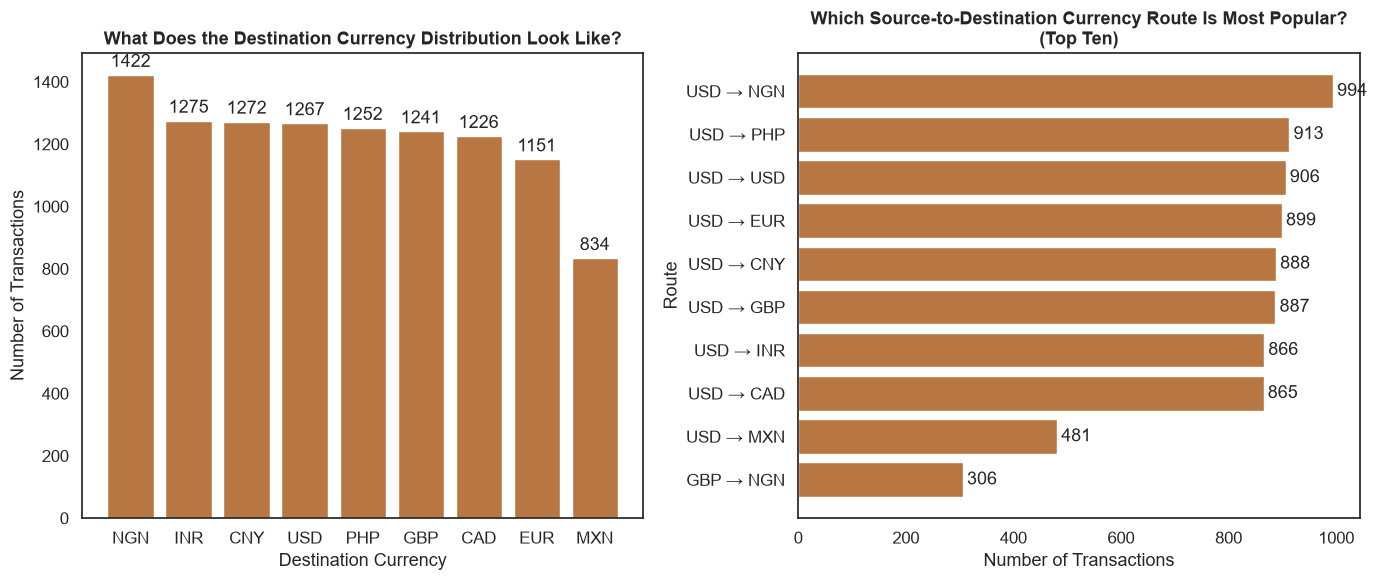

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()

# Q6: What does the destination currency distribution look like?
dest_counts = df_cleaned_transaction_data["dest_currency"].value_counts()
bars = axes[0].bar(dest_counts.index, dest_counts.values, color="#B87742")
axes[0].bar_label(bars, fmt="%d", padding=3)
axes[0].set_title("What Does the Destination Currency Distribution Look Like?")
axes[0].set_xlabel("Destination Currency")
axes[0].set_ylabel("Number of Transactions")

# Q7: Which source-to-destination currency route is most popular?
df_cleaned_transaction_data["currency_route"] = (
    df_cleaned_transaction_data["source_currency"] + " → " + df_cleaned_transaction_data["dest_currency"]
)
route_counts = df_cleaned_transaction_data["currency_route"].value_counts().head(10)  # top 10
bars = axes[1].barh(route_counts.index[::-1], route_counts.values[::-1], color="#B87742")
axes[1].bar_label(bars, fmt="%d", padding=3)
axes[1].set_title("Which Source-to-Destination Currency Route Is Most Popular?\n(Top Ten)")
axes[1].set_xlabel("Number of Transactions")
axes[1].set_ylabel("Route")

plt.tight_layout()
plt.show()

Destination currencies are fairly evenly spread, with **NGN** the most common (1,422) and **MXN** the least (834) — no single destination dominates.

The route breakdown shows **USD as the almost exclusive source currency** among the top 10 routes, with **USD → NGN** the most popular corridor (994 transactions). The one exception, **GBP → NGN** (306), still points to NGN as a consistently popular destination regardless of source currency.

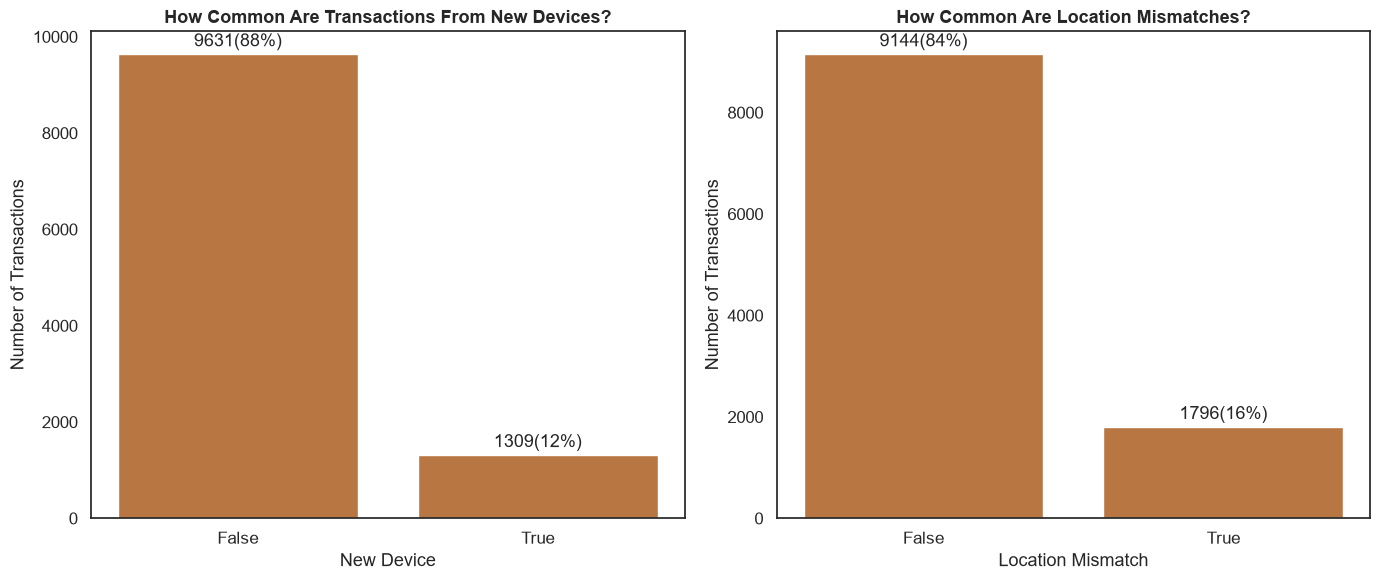

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes = axes.flatten()

# Q8: How common are transactions from new devices?
new_device_counts = df_cleaned_transaction_data["new_device"].value_counts()
new_device_pct = df_cleaned_transaction_data["new_device"].value_counts(normalize=True) * 100

bars = axes[0].bar(new_device_counts.index.astype(str), new_device_counts.values, color="#B87742")
labels = [f"{count}({pct:.0f}%)" for count, pct in zip(new_device_counts.values, new_device_pct.values)]
axes[0].bar_label(bars, labels=labels, padding=3)
axes[0].set_title("How Common Are Transactions From New Devices?")
axes[0].set_xlabel("New Device")
axes[0].set_ylabel("Number of Transactions")

# Q9: How common are location mismatches?
mismatch_counts = df_cleaned_transaction_data["location_mismatch"].value_counts()
mismatch_pct = df_cleaned_transaction_data["location_mismatch"].value_counts(normalize=True) * 100

bars = axes[1].bar(mismatch_counts.index.astype(str), mismatch_counts.values, color="#B87742")
labels = [f"{count}({pct:.0f}%)" for count, pct in zip(mismatch_counts.values, mismatch_pct.values)]
axes[1].bar_label(bars, labels=labels, padding=3)
axes[1].set_title("How Common Are Location Mismatches?")
axes[1].set_xlabel("Location Mismatch")
axes[1].set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

Most transactions come from **recognized devices** (88%) and **matching locations** (84%), meaning both risk indicators are relatively rare occurrences overall — new devices appear in only **12%** of transactions, and location mismatches in **16%**.

Since these signals are uncommon at the baseline level, their real value will show up in the next section: whether transactions carrying these flags are disproportionately associated with fraud.

In [47]:
def plot_distribution_grid(df, features, color="#B87742"):
    fig, axes = plt.subplots(len(features), 2, figsize=(14, 4 * len(features)))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        hist_ax = axes[i * 2]
        box_ax = axes[i * 2 + 1]

        # Histogram
        hist_ax.hist(df[feature], bins=40, color=color, edgecolor="white")
        hist_ax.set_title(f"What Does the Distribution of {feature} Look Like?")
        hist_ax.set_xlabel(feature)
        hist_ax.set_ylabel("Count")

        # Boxplot
        box_ax.boxplot(df[feature], orientation="vertical", patch_artist=True,
                        boxprops=dict(facecolor=color, color="black"),
                        medianprops=dict(color="black"))
        box_ax.set_title(f"What Is the Spread of {feature}?")
        box_ax.set_xticks([])
        box_ax.set_ylabel(feature)

    plt.tight_layout()
    plt.show()

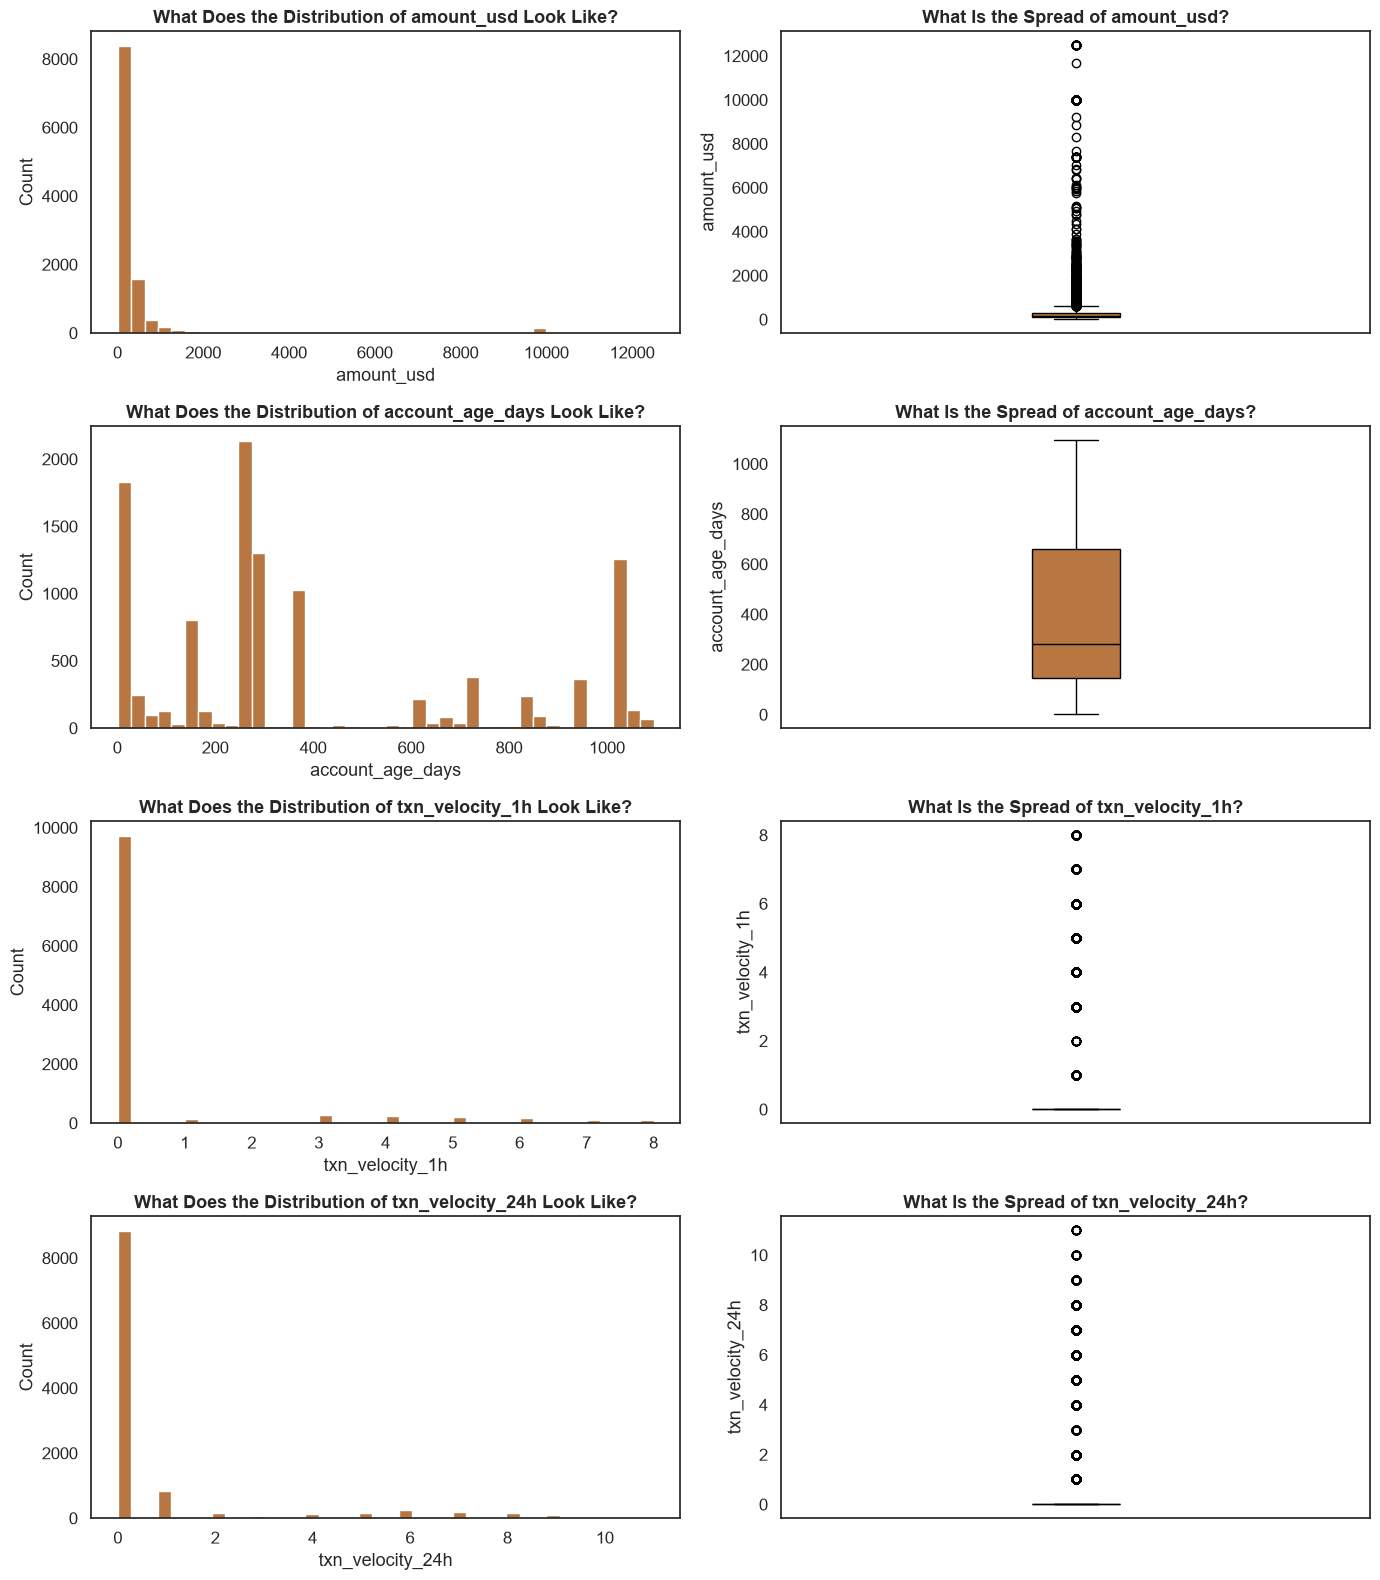

In [48]:
transaction_features = ["amount_usd", "account_age_days", "txn_velocity_1h", "txn_velocity_24h"]
plot_distribution_grid(df_cleaned_transaction_data, transaction_features)

##### Transaction Behavior: Amount, Account Age & Velocity

**Most transactions are small, but a few are very large.** Half of all transactions fall between **$93 and $303**, with a typical (median) transaction of about **$164** — but some transactions run as high as **$12,499**, showing up as a long tail of unusually large payments.

**Customers fall into a few distinct age groups rather than a smooth spread** — there are noticeable clusters of newer accounts, mid-tenure accounts (around 250-300 days old), and long-standing accounts (over 1,000 days), rather than customers being evenly spread across all account ages.

**The vast majority of customers make just one transaction at a time** — no other activity in the same hour or day. Only a small number of transactions happen back-to-back in quick succession, which stands out as unusual behavior worth watching closely once we compare it against fraud cases.

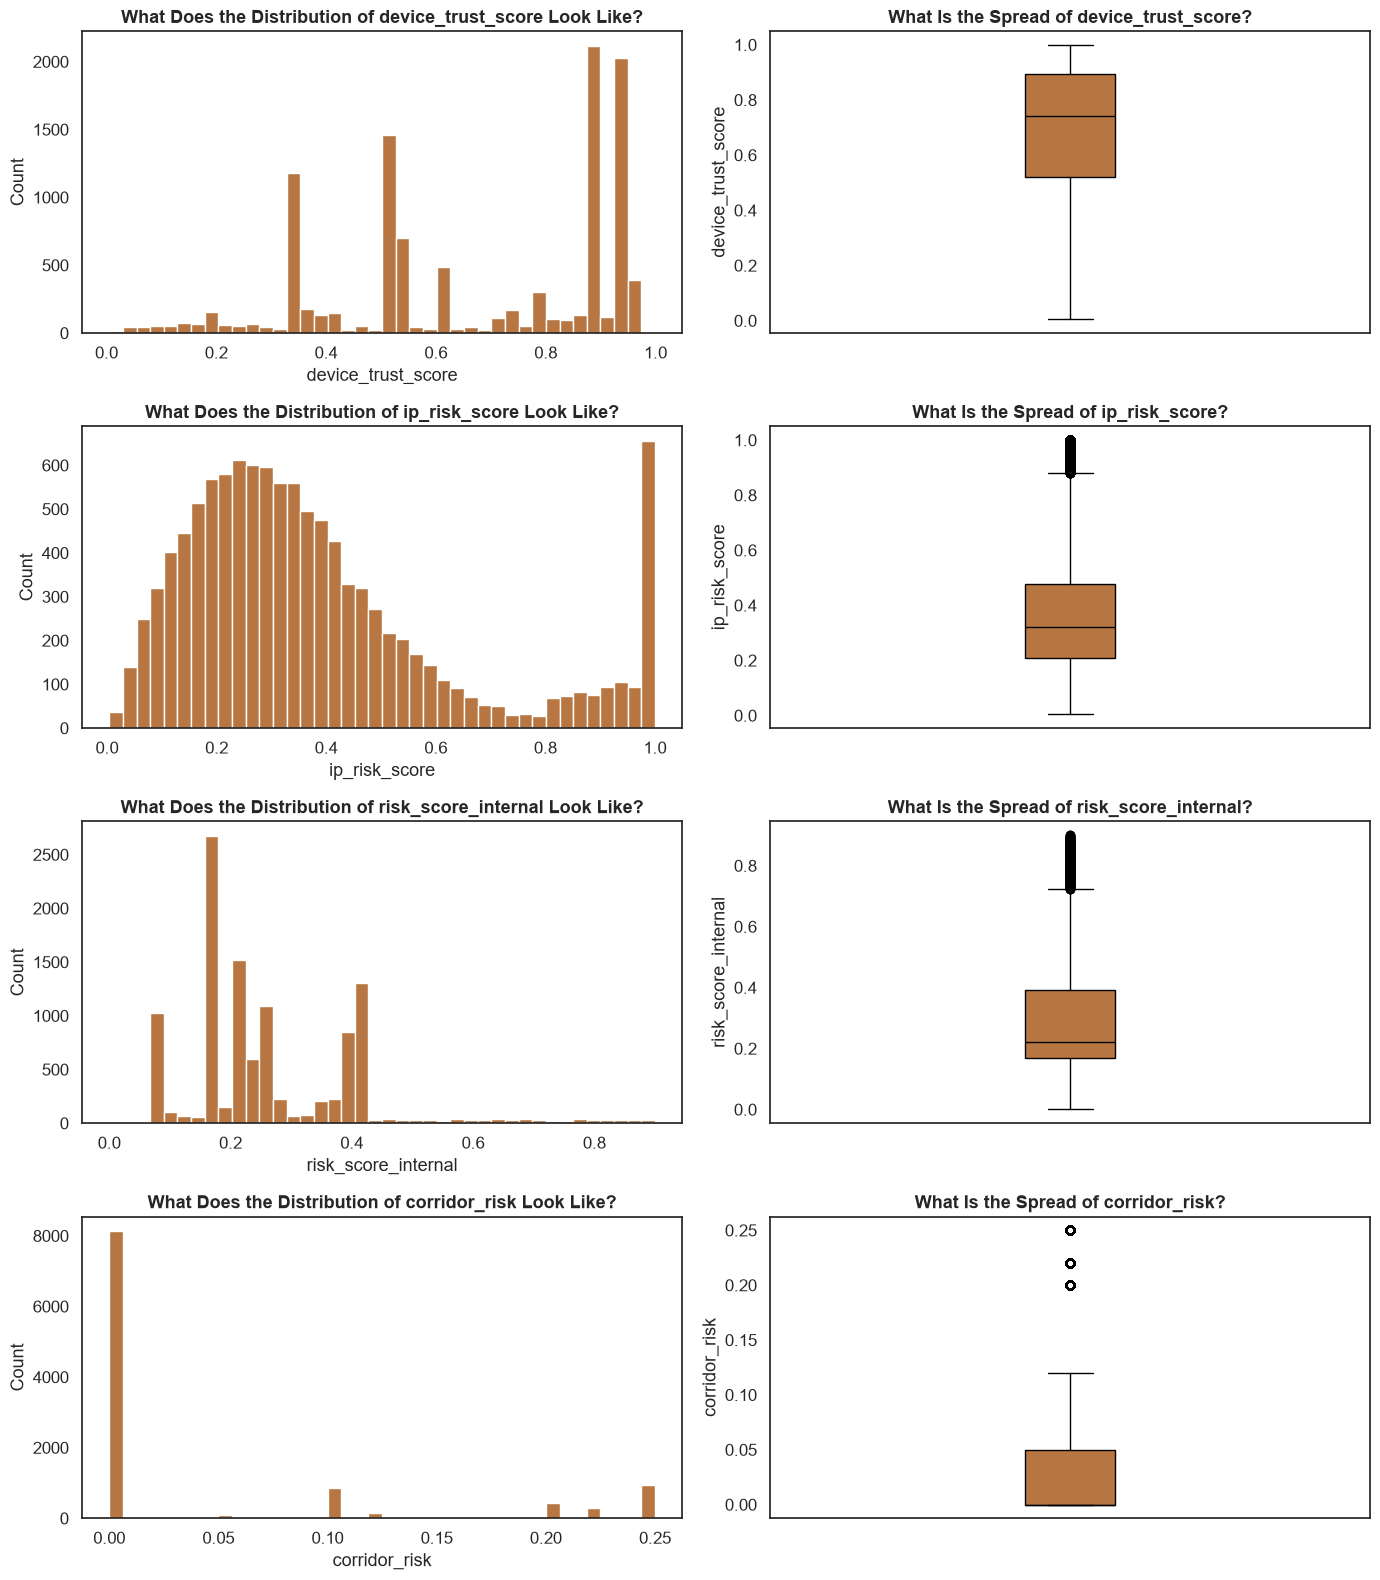

In [49]:
risk_features = ["device_trust_score", "ip_risk_score", "risk_score_internal", "corridor_risk"]
plot_distribution_grid(df_cleaned_transaction_data, risk_features)

##### Existing Risk Signals: Trust & Risk Scores

**Device trust score** reflects how much FinLora's system already trusts the device being used for a transaction, based on its history. Scores cluster around a few common values rather than spreading smoothly — most devices land either fairly high (around 0.9, indicating well-established, trusted devices) or moderately (around 0.5-0.6). Half of all devices score between **0.52 and 0.89**, suggesting devices tend to fall into a handful of trust tiers rather than being scored individually.

**IP risk score** flags how suspicious the location a transaction is coming from looks — based on signals like VPN use, proxies, or IPs previously linked to bad behavior. Most scores follow a natural spread, but there's a distinct spike of transactions scoring close to the maximum (near 1.0) — a small but clear group of highly suspicious origin locations sitting apart from the rest.

**Internal risk score** is FinLora's existing rule-based fraud score, so this tells us how the current system already rates each transaction before any new model gets involved. Most scores are low, with half of all transactions scoring below **0.22** — but a visible group of outliers scores much higher (above 0.7), standing out clearly in the boxplot.

**Corridor risk** captures how risky a specific money-transfer route (source-to-destination combination) has historically been — some country/currency pairings are simply more prone to fraud than others. This score is overwhelmingly zero for most transactions, meaning most routes are considered safe by default. A small number of specific corridors carry a distinctly higher risk score (up to 0.25), standing out as the exception rather than the norm.

Taken together, these are the risk signals FinLora already has in place — the next step is checking how well they actually line up with confirmed fraud cases.

### 2. Which Channels and Payment Routes Carry the Most Fraud Risk?

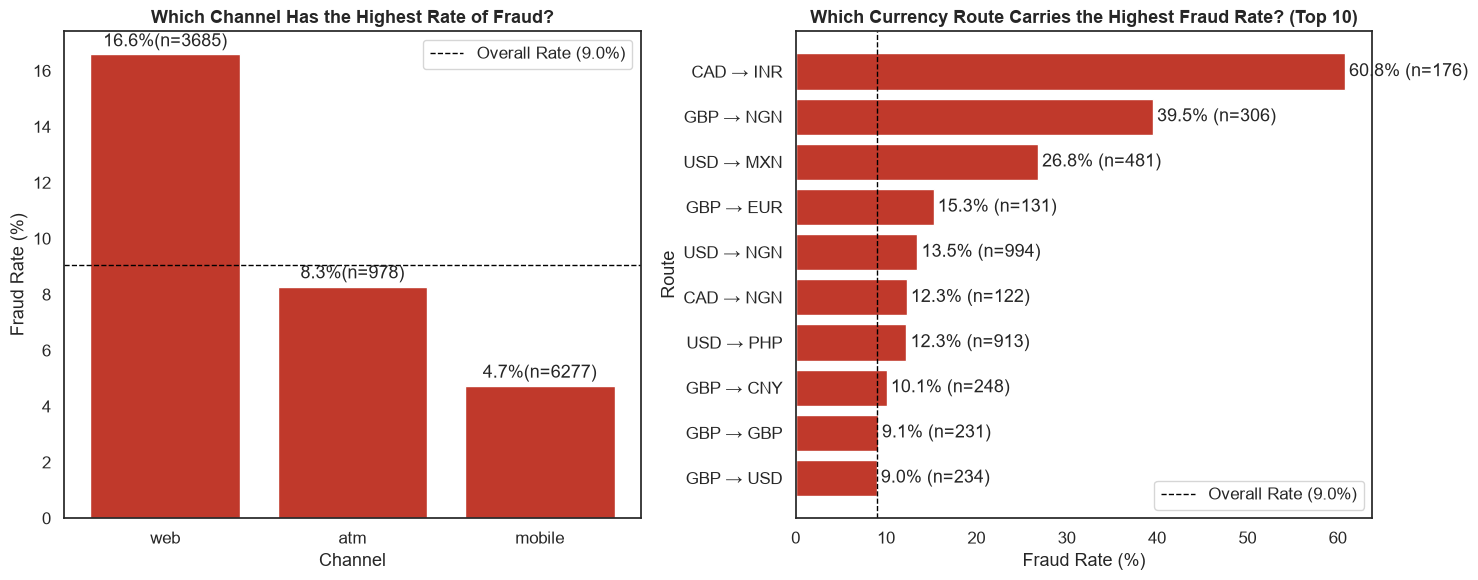

In [55]:
def fraud_rate_by_category(df, category_col, top_n=None):
    grouped = df.groupby(category_col)["is_fraud"].agg(["mean", "count"])
    grouped["fraud_rate_pct"] = grouped["mean"] * 100
    grouped = grouped.sort_values("fraud_rate_pct", ascending=False)
    if top_n:
        grouped = grouped.head(top_n)
    return grouped

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes = axes.flatten()

# Q: Which channel has the highest rate of fraud, not just the most transactions?
channel_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "channel")
bars = axes[0].bar(channel_fraud.index, channel_fraud["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}%(n={count})" for rate, count in zip(channel_fraud["fraud_rate_pct"], channel_fraud["count"])]
axes[0].bar_label(bars, labels=labels, padding=3)
overall_rate = df_cleaned_transaction_data["is_fraud"].mean() * 100
axes[0].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[0].set_title("Which Channel Has the Highest Rate of Fraud?")
axes[0].set_xlabel("Channel")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].legend()

# Q: Which source-to-destination currency route carries the highest fraud rate?
route_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "currency_route", top_n=10)
bars = axes[1].barh(route_fraud.index[::-1], route_fraud["fraud_rate_pct"][::-1], color="#C0392B")
labels = [f"{rate:.1f}% (n={count})" for rate, count in zip(route_fraud["fraud_rate_pct"][::-1], route_fraud["count"][::-1])]
axes[1].bar_label(bars, labels=labels, padding=3)
axes[1].axvline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[1].set_title("Which Currency Route Carries the Highest Fraud Rate? (Top 10)")
axes[1].set_xlabel("Fraud Rate (%)")
axes[1].set_ylabel("Route")
axes[1].legend()

plt.tight_layout()
plt.show()

**Web transactions are disproportionately risky.** Despite carrying less volume than mobile, **web** has a fraud rate of **16.6%** — nearly double the overall fraudulent rate of 9.0%. **Mobile**, by contrast, sits well below average at **4.7%**, despite handling the most transactions overall. This suggests fraud risk depends far more on *which channel* is used than on how much volume passes through it.

**A small number of currency routes carry extreme fraud risk.** The **CAD → INR** corridor stands out sharply, with **60.8%** of its transactions flagged as fraudulent — more than 6x the overall rate. **GBP → NGN** (39.5%) and **USD → MXN** (26.8%) also show fraud rates well above baseline. Most other routes hover close to or below the 9.0% average.

**Sample size matters here.** Some of the highest-risk routes involve relatively few transactions (e.g., CAD → INR at n=176, GBP → EUR at n=131), so while the pattern is worth flagging, these rates are based on smaller samples and should be treated as a strong signal to investigate further — not a fully confirmed pattern — compared to higher-volume routes like USD → NGN (n=994).

### 3. How Does Account Age, KYC Verification Status and Chargeback History Relate to Fraud?

C:\Users\leest\AppData\Local\Temp\ipykernel_64376\3990478663.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(category_col)["is_fraud"].agg(["mean", "count"])


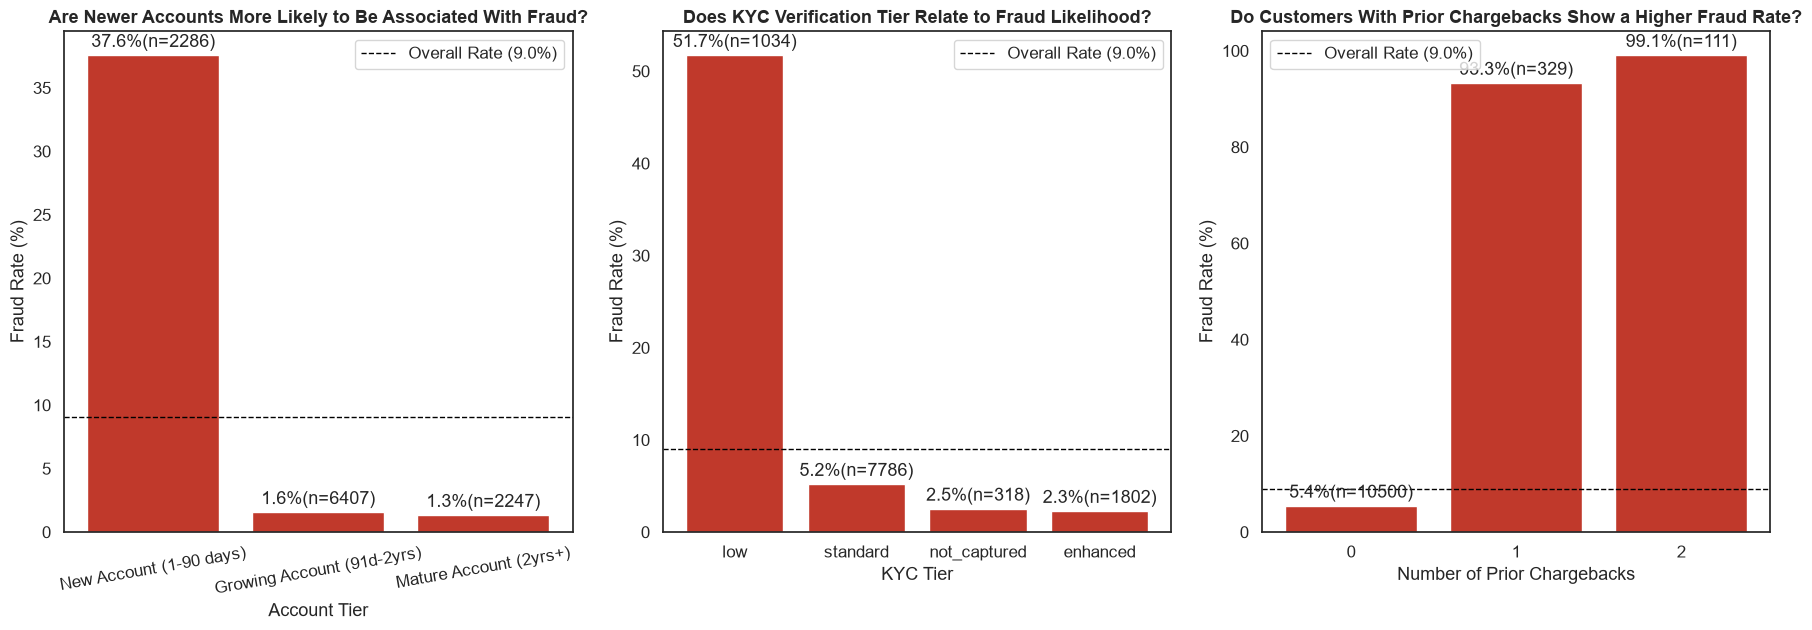

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
axes = axes.flatten()

# Q1: Are newer accounts more likely to be associated with fraud than older ones?
# Create account age tier bins
bins = [0, 90, 730, df_cleaned_transaction_data["account_age_days"].max()]
labels = [
    "New Account (1-90 days)",
    "Growing Account (91d-2yrs)",
    "Mature Account (2yrs+)"
]

df_cleaned_transaction_data["account_age_tier"] = pd.cut(
    df_cleaned_transaction_data["account_age_days"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

age_tier_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "account_age_tier")
age_tier_fraud = age_tier_fraud.reindex(labels)

bars = axes[0].bar(age_tier_fraud.index, age_tier_fraud["fraud_rate_pct"], color="#C0392B")
plot_labels = [f"{rate:.1f}%(n={count})" for rate, count in zip(age_tier_fraud["fraud_rate_pct"], age_tier_fraud["count"])]
axes[0].bar_label(bars, labels=plot_labels, padding=3)
axes[0].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[0].set_title("Are Newer Accounts More Likely to Be Associated With Fraud?")
axes[0].set_xlabel("Account Tier")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].tick_params(axis='x', rotation=10)
axes[0].legend()

# Q2: Does KYC verification tier relate to fraud likelihood?
kyc_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "kyc_tier")
bars = axes[1].bar(kyc_fraud.index, kyc_fraud["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}%(n={count})" for rate, count in zip(kyc_fraud["fraud_rate_pct"], kyc_fraud["count"])]
axes[1].bar_label(bars, labels=labels, padding=3)
axes[1].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[1].set_title("Does KYC Verification Tier Relate to Fraud Likelihood?")
axes[1].set_xlabel("KYC Tier")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].legend()

# Q3: Do customers with prior chargebacks show a higher fraud rate?
chargeback_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "chargeback_history_count")
chargeback_fraud = chargeback_fraud.sort_index()  # keep natural order: 0, 1, 2...
bars = axes[2].bar(chargeback_fraud.index.astype(str), chargeback_fraud["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}%(n={count})" for rate, count in zip(chargeback_fraud["fraud_rate_pct"], chargeback_fraud["count"])]
axes[2].bar_label(bars, labels=labels, padding=3)
axes[2].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[2].set_title("Do Customers With Prior Chargebacks Show a Higher Fraud Rate?")
axes[2].set_xlabel("Number of Prior Chargebacks")
axes[2].set_ylabel("Fraud Rate (%)")
axes[2].legend()

plt.tight_layout()
plt.show()

**New accounts are more fraud-prone.** Accounts less than 90 days old show a fraud rate of **37.6%** — over 4x the overall rate of 9.0% — compared to just **1.6%** for Growing accounts and **1.3%** for Mature accounts (2+ years).

PS: FinLora's account age classification/grouping
- 1 day to 90 days = New account
- 91 days to 730 days (2 years) = Growing account
- 731 days above = Mature account


**Lower KYC verification is strongly linked to higher fraud.** Customers at the **low** verification tier show a fraud rate of **51.7%** — nearly 6x the baseline — while **standard** (5.2%), **not_captured** (2.5%), and **enhanced** (2.3%) tiers all sit at or below the overall rate. This suggests weaker identity verification is one of the clearest fraud indicators available, and reinforces the value of KYC checks as a first line of defense.

**Prior chargebacks are an almost perfect fraud predictor.** Customers with **zero** prior chargebacks show a fraud rate close to baseline (**5.4%**), but this jumps to **88.3%** with one prior chargeback and **99.1%** with two — meaning a customer with any chargeback history is overwhelmingly likely to be involved in a fraudulent transaction. Worth noting the sample sizes here are much smaller (n=329 and n=111) than the zero-chargeback group (n=10,500), but the effect size is large enough that this is unlikely to be noise.

Together, these three factors — account age, KYC tier, and chargeback history — appear to be some of the most powerful fraud signals uncovered, and are strong candidates for feature engineering ahead of modelling.

### 4. What Device and Location Signals Stand Out?

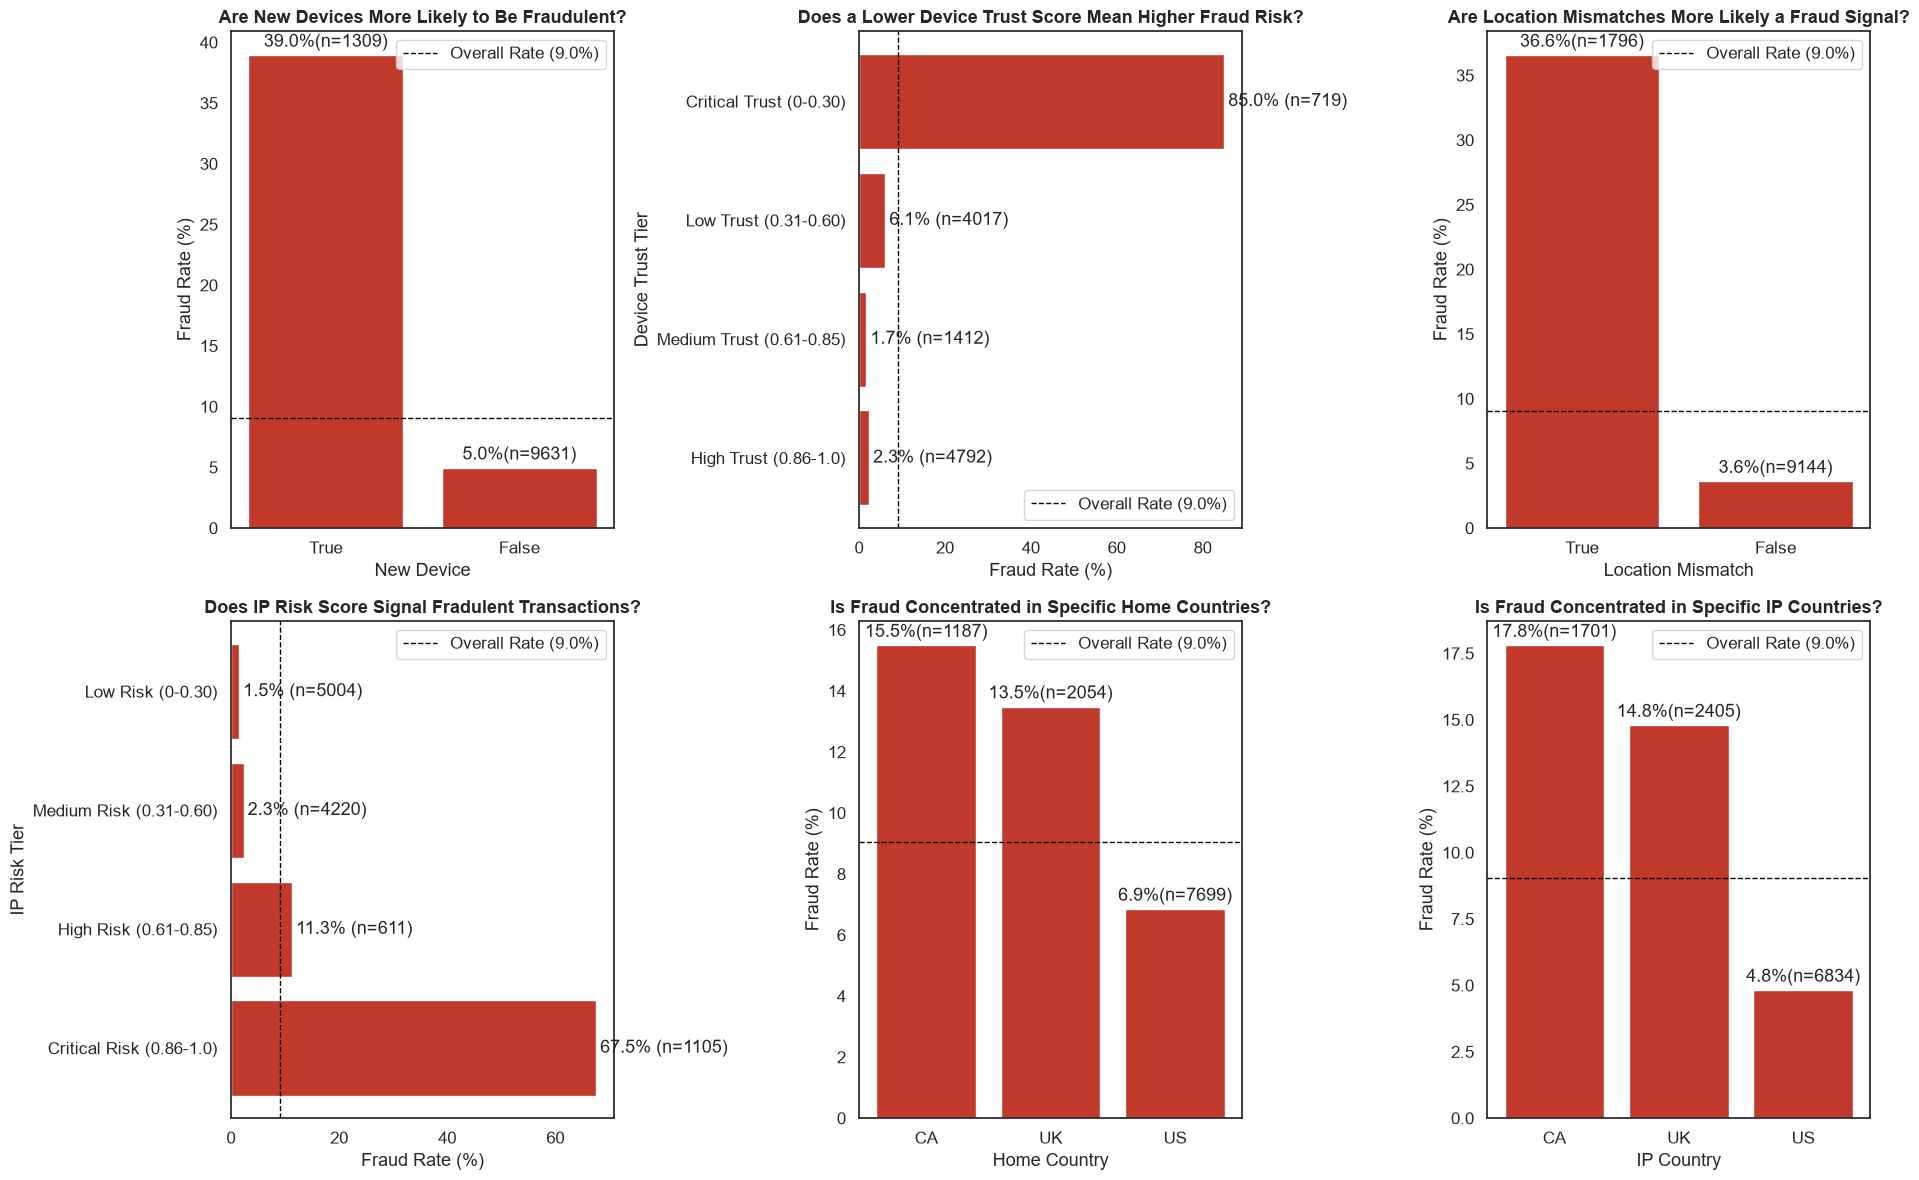

In [78]:
def fraud_rate_by_category(df, category_col, top_n=None):
    grouped = df.groupby(category_col, observed=False)["is_fraud"].agg(["mean", "count"])
    grouped["fraud_rate_pct"] = grouped["mean"] * 100
    grouped = grouped.sort_values("fraud_rate_pct", ascending=False)
    if top_n:
        grouped = grouped.head(top_n)
    return grouped

# 4-tier fraud-risk convention
risk_bins = [0, 0.30, 0.60, 0.85, 1.0]

df_cleaned_transaction_data["ip_risk_tier"] = pd.cut(
    df_cleaned_transaction_data["ip_risk_score"],
    bins=risk_bins,
    labels=["Low Risk (0-0.30)", "Medium Risk (0.31-0.60)", "High Risk (0.61-0.85)", "Critical Risk (0.86-1.0)"],
    include_lowest=True
)

# Note: device_trust_score is inverted - LOW trust = HIGH risk
df_cleaned_transaction_data["device_trust_tier"] = pd.cut(
    df_cleaned_transaction_data["device_trust_score"],
    bins=risk_bins,
    labels=["Critical Trust (0-0.30)", "Low Trust (0.31-0.60)", "Medium Trust (0.61-0.85)", "High Trust (0.86-1.0)"],
    include_lowest=True
)

fig, axes = plt.subplots(2, 3, figsize=(19, 12))
axes = axes.flatten()

# Q1: Are transactions from new devices more likely to be fraudulent?
new_device_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "new_device")
bars = axes[0].bar(new_device_fraud.index.astype(str), new_device_fraud["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}%(n={count})" for rate, count in zip(new_device_fraud["fraud_rate_pct"], new_device_fraud["count"])]
axes[0].bar_label(bars, labels=labels, padding=3)
axes[0].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[0].set_title("Are New Devices More Likely to Be Fraudulent?")
axes[0].set_xlabel("New Device")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].legend()

# Q2: Does a lower device trust score correlate with fraud?
trust_order = ["Critical Trust (0-0.30)", "Low Trust (0.31-0.60)", "Medium Trust (0.61-0.85)", "High Trust (0.86-1.0)"]
trust_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "device_trust_tier").reindex(trust_order)
bars = axes[1].barh(trust_fraud.index[::-1], trust_fraud["fraud_rate_pct"][::-1], color="#C0392B")
labels = [f"{rate:.1f}% (n={count})" for rate, count in zip(trust_fraud["fraud_rate_pct"][::-1], trust_fraud["count"][::-1])]
axes[1].bar_label(bars, labels=labels, padding=3)
axes[1].axvline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[1].set_title("Does a Lower Device Trust Score Mean Higher Fraud Risk?")
axes[1].set_xlabel("Fraud Rate (%)")
axes[1].set_ylabel("Device Trust Tier")
axes[1].legend()

# Q3: Are transactions with a location mismatch more likely to be fraud?
mismatch_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "location_mismatch")
bars = axes[2].bar(mismatch_fraud.index.astype(str), mismatch_fraud["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}%(n={count})" for rate, count in zip(mismatch_fraud["fraud_rate_pct"], mismatch_fraud["count"])]
axes[2].bar_label(bars, labels=labels, padding=3)
axes[2].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[2].set_title("Are Location Mismatches More Likely a Fraud Signal?")
axes[2].set_xlabel("Location Mismatch")
axes[2].set_ylabel("Fraud Rate (%)")
axes[2].legend()

# Q4: Does IP risk score meaningfully separate fraud from legitimate transactions?
risk_order = ["Low Risk (0-0.30)", "Medium Risk (0.31-0.60)", "High Risk (0.61-0.85)", "Critical Risk (0.86-1.0)"]
ip_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "ip_risk_tier").reindex(risk_order)
bars = axes[3].barh(ip_fraud.index[::-1], ip_fraud["fraud_rate_pct"][::-1], color="#C0392B")
labels = [f"{rate:.1f}% (n={count})" for rate, count in zip(ip_fraud["fraud_rate_pct"][::-1], ip_fraud["count"][::-1])]
axes[3].bar_label(bars, labels=labels, padding=3)
axes[3].axvline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[3].set_title("Does IP Risk Score Signal Fradulent Transactions?")
axes[3].set_xlabel("Fraud Rate (%)")
axes[3].set_ylabel("IP Risk Tier")
axes[3].legend()

# Q5: Is fraud concentrated in specific home countries?
home_country_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "home_country")
bars = axes[4].bar(home_country_fraud.index, home_country_fraud["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}%(n={count})" for rate, count in zip(home_country_fraud["fraud_rate_pct"], home_country_fraud["count"])]
axes[4].bar_label(bars, labels=labels, padding=3)
axes[4].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[4].set_title("Is Fraud Concentrated in Specific Home Countries?")
axes[4].set_xlabel("Home Country")
axes[4].set_ylabel("Fraud Rate (%)")
axes[4].legend()

# Q6: Is fraud concentrated in specific IP countries?
ip_country_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "ip_country")
bars = axes[5].bar(ip_country_fraud.index, ip_country_fraud["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}%(n={count})" for rate, count in zip(ip_country_fraud["fraud_rate_pct"], ip_country_fraud["count"])]
axes[5].bar_label(bars, labels=labels, padding=3)
axes[5].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[5].set_title("Is Fraud Concentrated in Specific IP Countries?")
axes[5].set_xlabel("IP Country")
axes[5].set_ylabel("Fraud Rate (%)")
axes[5].legend()

plt.tight_layout()
plt.show()

**New devices are a strong fraud signal.** Transactions from a new/unrecognised device show a fraud rate of **39.0%** — over 4x the overall rate — compared to just **5.0%** for recognised devices. 

**Device trust score confirms this pattern almost perfectly.** Transactions with the lowest trust ("Critical Trust", 0-0.30) show an **85.0%** fraud rate. This makes intuitive sense: `new_device` and `device_trust_score` are effectively measuring overlapping behavior, both flagging unfamiliar hardware as high risk.

**Location mismatches are another clear red flag.** When a customer's declared location doesn't match their IP-inferred location, fraud rate jumps to **36.6%**, versus **3.6%** when they match — reinforcing that unfamiliar or inconsistent signals (device, location) are where fraud consistently concentrates.

**IP risk score shows a non-linear, U-shaped pattern worth noting.** Fraud rate is low at both "Low Risk" (1.5%) and "Medium Risk" (2.3%), but jumps sharply at "High Risk" (11.3%) and dramatically at "Critical Risk" (**67.5%**)

**Geography plays a smaller but still visible role.** Althoughb most transactions happen from the US, Fraud rates by both home country and IP country follow the same order — **CA highest (15.5% / 17.8%)**, then **UK (13.5% / 14.8%)**, then **US lowest (6.9% / 4.8%)**

**The throughline across Sections 3 and 4:** the strongest fraud predictors so far are all forms of the same underlying idea — **unfamiliarity**. New accounts, new devices, low trust scores, and location mismatches all point to the same conclusion: fraud in this dataset is overwhelmingly associated with *unrecogniSed* customers, devices, and locations.

### 5. Transaction Velocity/Seasonality and Risk Rate

In [84]:
df_cleaned_transaction_data["timestamp"].describe()

count                                  10940
mean     2024-05-02 20:35:02.626325504+00:00
min         2022-10-03 18:40:59.468549+00:00
25%      2023-08-14 12:03:57.968549120+00:00
50%      2024-05-08 15:22:15.968549120+00:00
75%      2025-01-29 18:35:17.468549120+00:00
max         2025-12-16 00:13:41.468549+00:00
Name: timestamp, dtype: object

In [95]:
df_cleaned_transaction_data["txn_year"].value_counts()

txn_year
2024    3864
2023    3294
2025    3017
2022     765
Name: count, dtype: int64

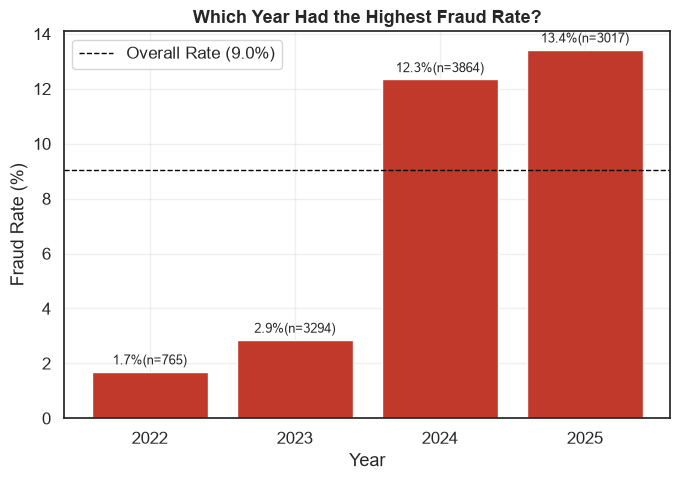

In [98]:
year_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "txn_year").sort_index()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(year_fraud.index.astype(str), year_fraud["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}%(n={count})" for rate, count in zip(year_fraud["fraud_rate_pct"], year_fraud["count"])]
ax.bar_label(bars, labels=labels, padding=3, fontsize=9)
overall_rate_line = ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
ax.set_title("Which Year Had the Highest Fraud Rate?")
ax.set_xlabel("Year")
ax.set_ylabel("Fraud Rate (%)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

**Fraud Rate Is Rising Year Over Year**:Fraud has climbed significantly since 2022 — from just **1.7%** to **13.4%** in 2025, now well above the overall average of 9.0%. The data spans transactions from **October 3, 2022** to **December 16, 2025**, showing a clear and accelerating upward trend rather than a one-off spike.

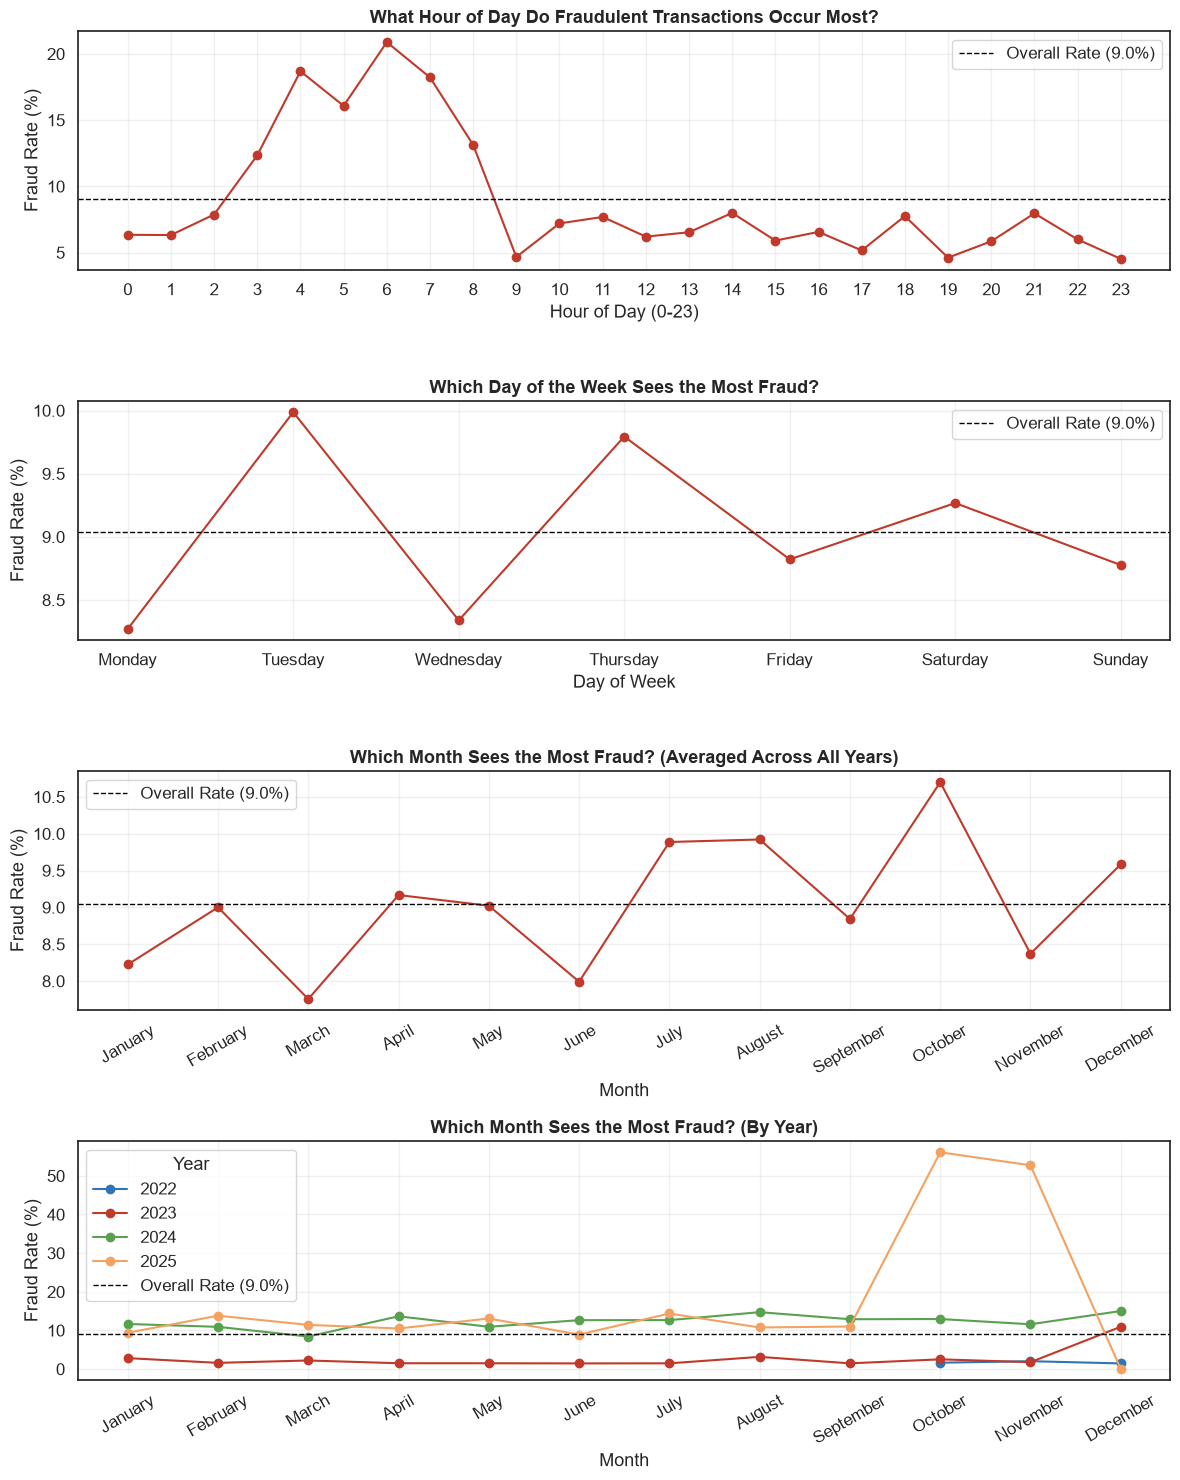

In [89]:
# Extract time-based features directly from the timestamp column
df_cleaned_transaction_data["txn_hour"] = df_cleaned_transaction_data["timestamp"].dt.hour
df_cleaned_transaction_data["txn_day_of_week"] = df_cleaned_transaction_data["timestamp"].dt.day_name()
df_cleaned_transaction_data["txn_month_name"] = df_cleaned_transaction_data["timestamp"].dt.month_name()
df_cleaned_transaction_data["txn_year"] = df_cleaned_transaction_data["timestamp"].dt.year

month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

fig, axes = plt.subplots(4, 1, figsize=(12, 15))

# Q1: What hour of day do fraudulent transactions occur most?
hour_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "txn_hour").sort_index()
axes[0].plot(hour_fraud.index, hour_fraud["fraud_rate_pct"], marker="o", color="#C0392B")
axes[0].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[0].set_title("What Hour of Day Do Fraudulent Transactions Occur Most?")
axes[0].set_xlabel("Hour of Day (0-23)")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Q2: Which day of the week sees the most fraud?
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "txn_day_of_week").reindex(day_order)
axes[1].plot(day_fraud.index, day_fraud["fraud_rate_pct"], marker="o", color="#C0392B")
axes[1].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[1].set_title("Which Day of the Week Sees the Most Fraud?")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Q3 - OPTION A: Month pattern, averaged across all years
month_avg_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "txn_month_name").reindex(month_order)
axes[2].plot(month_avg_fraud.index, month_avg_fraud["fraud_rate_pct"], marker="o", color="#C0392B")
axes[2].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[2].set_title("Which Month Sees the Most Fraud? (Averaged Across All Years)")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Fraud Rate (%)")
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

# Q3 - OPTION B: Month pattern, one line per year
for year in sorted(df_cleaned_transaction_data["txn_year"].unique()):
    year_data = df_cleaned_transaction_data[df_cleaned_transaction_data["txn_year"] == year]
    month_year_fraud = fraud_rate_by_category(year_data, "txn_month_name").reindex(month_order)
    axes[3].plot(month_year_fraud.index, month_year_fraud["fraud_rate_pct"], marker="o", label=str(year))

axes[3].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[3].set_title("Which Month Sees the Most Fraud? (By Year)")
axes[3].set_xlabel("Month")
axes[3].set_ylabel("Fraud Rate (%)")
axes[3].tick_params(axis='x', rotation=30)
axes[3].grid(True, alpha=0.3)
axes[3].legend(title="Year")

plt.tight_layout()
plt.show()

**Fraud spikes sharply during early morning hours.** Fraud rate climbs from a baseline of ~6-8% starting at 2am, peaking at **21%** around 6am, before dropping back to normal levels by 9am. This late-night/early-morning window — when legitimate customer activity is typically lowest — stands out as the clearest time-based fraud signal in the dataset.

**Day of week shows a mild but visible pattern.** Tuesday (10.0%) and Thursday (9.8%) see the highest fraud rates, while Monday (8.3%) and Wednesday (8.3%) sit lowest — a real but modest effect compared to the hour-of-day finding.

**Monthly patterns are unstable once broken out by year.** Averaged across all years, fraud looks relatively flat, with only a mild October uptick (10.7%). But splitting by year reveals a very different picture: **2025 shows an extreme spike in October (56%) and November (53%)** — far above every other year and month — while 2022-2024 stayed comparatively stable throughout.

Worth noting that most 2025 fradulent transactions are concentrated in these two months. This makes the October-November 2025 surge worth flagging as a potential fraud event to investigate further, rather than confirming it as a recurring seasonal pattern.

### 6. How Well Does FinLora's Existing Scoring Actually Work?

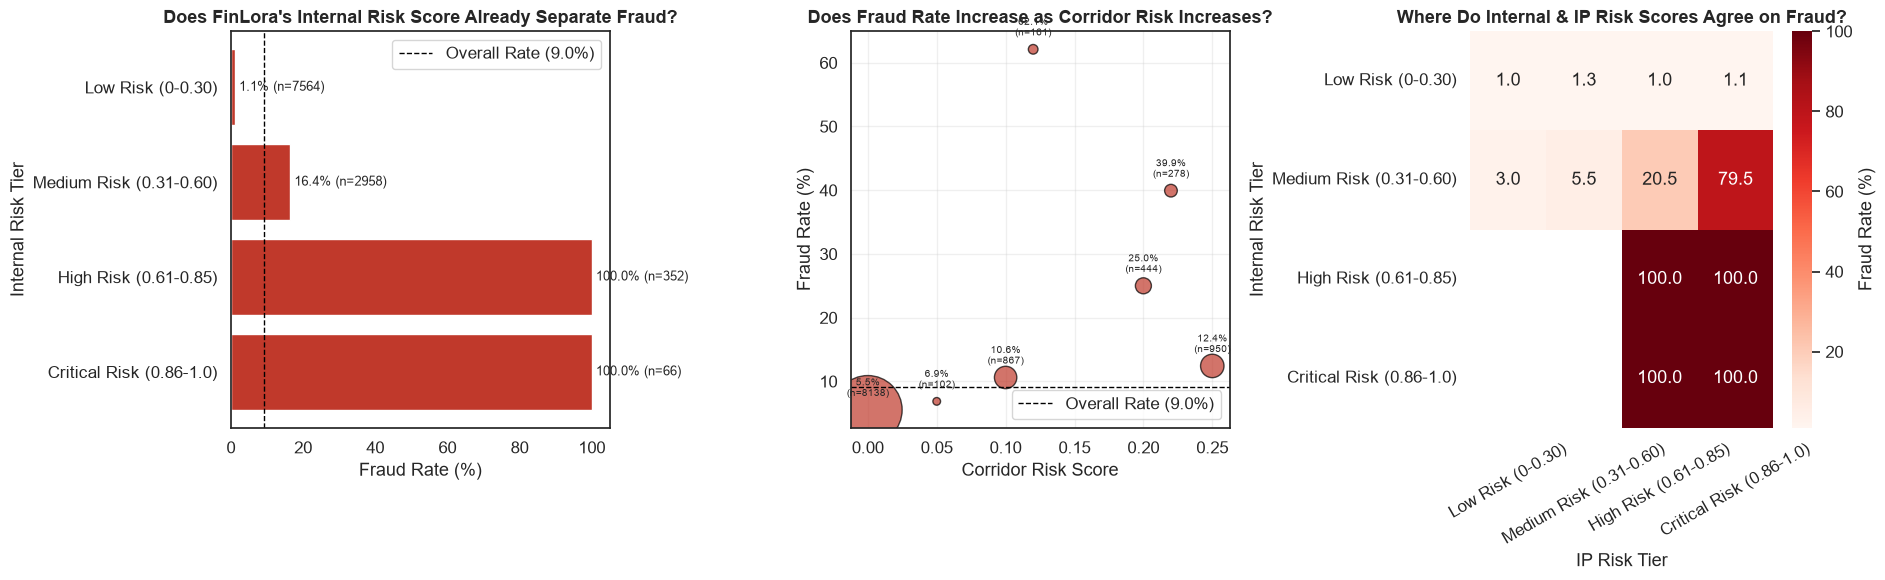

In [106]:
# Bin internal risk score using the same 4-tier convention as ip_risk_score
df_cleaned_transaction_data["internal_risk_tier"] = pd.cut(
    df_cleaned_transaction_data["risk_score_internal"],
    bins=risk_bins,
    labels=["Low Risk (0-0.30)", "Medium Risk (0.31-0.60)", "High Risk (0.61-0.85)", "Critical Risk (0.86-1.0)"],
    include_lowest=True
)

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
axes = axes.flatten()

# Q1: How well does the existing internal risk score already separate fraud from legitimate transactions?
internal_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "internal_risk_tier").reindex(risk_order)
bars = axes[0].barh(internal_fraud.index[::-1], internal_fraud["fraud_rate_pct"][::-1], color="#C0392B")
labels = [f"{rate:.1f}% (n={count})" for rate, count in zip(internal_fraud["fraud_rate_pct"][::-1], internal_fraud["count"][::-1])]
axes[0].bar_label(bars, labels=labels, padding=3, fontsize=9)
axes[0].axvline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[0].set_title("Does FinLora's Internal Risk Score Already Separate Fraud?")
axes[0].set_xlabel("Fraud Rate (%)")
axes[0].set_ylabel("Internal Risk Tier")
axes[0].legend()

# Q2: Does fraud rate increase as corridor risk increases? (Bubble chart - size = sample count)
corridor_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "corridor_risk").sort_index()
axes[1].scatter(
    corridor_fraud.index,
    corridor_fraud["fraud_rate_pct"],
    s=corridor_fraud["count"] * 0.3,
    color="#C0392B",
    alpha=0.7,
    edgecolor="black"
)
for x, y, n in zip(corridor_fraud.index, corridor_fraud["fraud_rate_pct"], corridor_fraud["count"]):
    axes[1].annotate(f"{y:.1f}%\n(n={n})", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=7)
axes[1].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[1].set_title("Does Fraud Rate Increase as Corridor Risk Increases?")
axes[1].set_xlabel("Corridor Risk Score")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Q3: Where do internal risk score and IP risk score agree or disagree on flagging a transaction?
agreement_pivot = df_cleaned_transaction_data.pivot_table(
    values="is_fraud",
    index="internal_risk_tier",
    columns="ip_risk_tier",
    aggfunc="mean",
    observed=False
) * 100
agreement_pivot = agreement_pivot.reindex(index=risk_order, columns=risk_order)

sns.heatmap(agreement_pivot, annot=True, fmt=".1f", cmap="Reds", ax=axes[2], cbar_kws={"label": "Fraud Rate (%)"})
axes[2].set_title("Where Do Internal & IP Risk Scores Agree on Fraud?")
axes[2].set_xlabel("IP Risk Tier")
axes[2].set_ylabel("Internal Risk Tier")
axes[2].tick_params(axis='x', rotation=30)
axes[2].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

**FinLora's rule-based internal risk score is a surprisingly strong predictor on its own.** Transactions rated "Low Risk" show a fraud rate of just **1.1%**, while "High Risk" and "Critical Risk" transactions are **100% fraudulent** — a near-perfect separation at the extremes. This is a genuinely strong signal, and suggests the internal system already captures something real about fraud. However, there's clear room for improvement in the "Medium Risk" band, where the score alone struggles to reliably separate fraud from legitimate activity.

**Corridor risk tells a messier story.** Fraud rate generally rises with corridor risk score, but not consistently — a score of **0.12 shows the highest fraud rate (62.4%)**, higher than the supposedly riskier 0.20, 0.22, and even the maximum 0.25 score. This means the corridor scoring isn't reliably ranked — a corridor rated "medium" can, in practice, be riskier than one rated "highest," which limits how much analysts can trust the score at face value.

**The two scores add the most value together in the "Medium" zone.** When the internal score already says "Low Risk," fraud stays low (1.0-1.3%) no matter what the IP risk score says — and when it says "High" or "Critical," fraud is 100% either way. But in the **"Medium Risk"** internal band, the IP risk score becomes genuinely useful: fraud rate ranges from just **3%** (when IP risk is also low) up to **79.5%** (when IP risk is critical) — a huge swing the internal score alone can't explain.

**What this means for FinLora's current system: FinLora's internal score is great at spotting the obvious cases (very safe or very risky), but it goes "blind" in the middle. That's exactly where a second signal — like IP risk score, or eventually your machine learning model — adds the most value: not by replacing what already works, but by resolving the cases the current system can't confidently call on its own.**

### 7. How Much Money Is Involved? (Amount, Fees & Channel)

In [113]:
q1 = df_cleaned_transaction_data["amount_usd"].quantile(0.25)
q3 = df_cleaned_transaction_data["amount_usd"].quantile(0.75)
iqr = q3 - q1

print("=== amount_usd: Measures of Central Tendency & Spread ===")
print(f"Mean:    ${df_cleaned_transaction_data['amount_usd'].mean():.2f}")
print(f"Median:  ${df_cleaned_transaction_data['amount_usd'].median():.2f}")
print(f"Mode:    ${df_cleaned_transaction_data['amount_usd'].mode()[0]:.2f}")
print(f"Std Dev: ${df_cleaned_transaction_data['amount_usd'].std():.2f}")
print(f"Min:     ${df_cleaned_transaction_data['amount_usd'].min():.2f}")
print(f"Q1 (25%):${q1:.2f}")
print(f"Q3 (75%):${q3:.2f}")
print(f"IQR:     ${iqr:.2f}")
print(f"Max:     ${df_cleaned_transaction_data['amount_usd'].max():.2f}")

=== amount_usd: Measures of Central Tendency & Spread ===
Mean:    $448.72
Median:  $163.63
Mode:    $100.00
Std Dev: $1389.70
Min:     $7.23
Q1 (25%):$92.54
Q3 (75%):$303.08
IQR:     $210.54
Max:     $12498.58


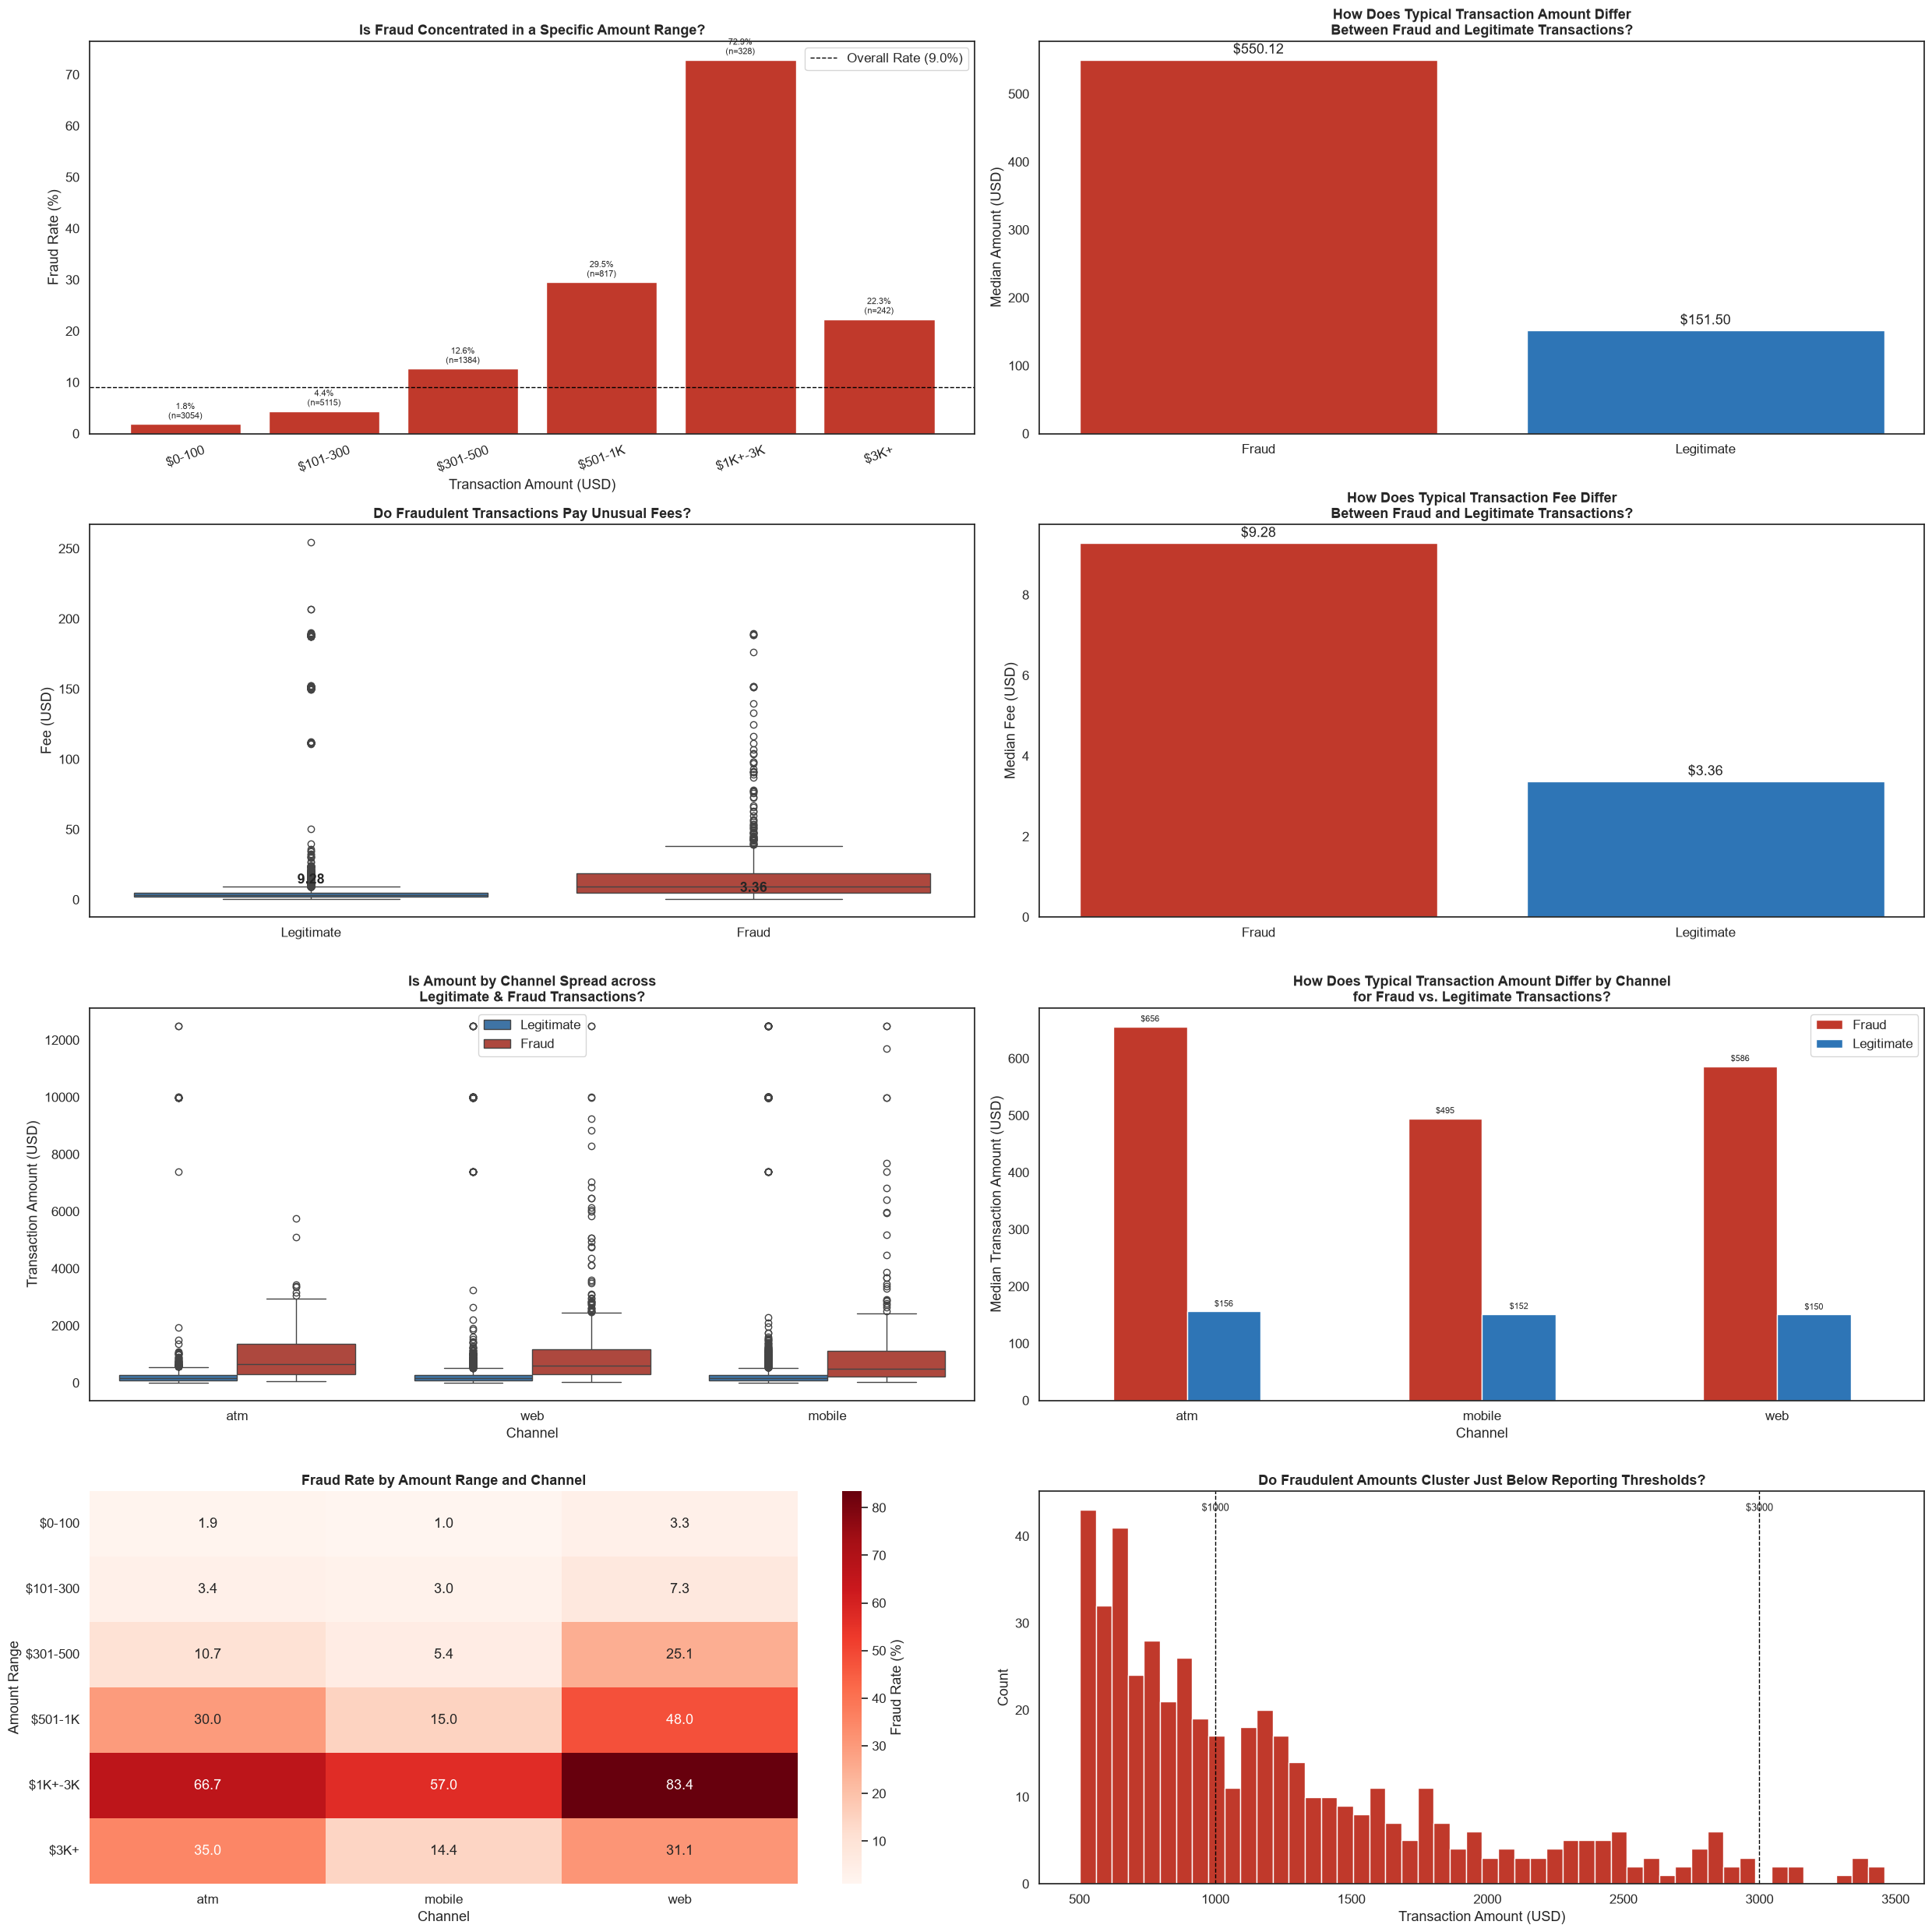

In [131]:
# Bin amount_usd into readable ranges
amount_bins = [0, 100, 300, 500, 1000, 3000, df_cleaned_transaction_data["amount_usd"].max()]
amount_labels = ["$0-100", "$101-300", "$301-500", "$501-1K", "$1K+-3K", "$3K+"]

df_cleaned_transaction_data["amount_range"] = pd.cut(
    df_cleaned_transaction_data["amount_usd"],
    bins=amount_bins,
    labels=amount_labels,
    include_lowest=True
)

fig, axes = plt.subplots(4, 2, figsize=(25, 25))
axes = axes.flatten()

# Q1: Are fraudulent transactions associated with higher amounts, and where does fraud concentrate?
amount_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "amount_range").reindex(amount_labels)
bars = axes[0].bar(amount_fraud.index, amount_fraud["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}%\n(n={count})" for rate, count in zip(amount_fraud["fraud_rate_pct"], amount_fraud["count"])]
axes[0].bar_label(bars, labels=labels, padding=3, fontsize=8)
axes[0].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[0].set_title("Is Fraud Concentrated in a Specific Amount Range?")
axes[0].set_xlabel("Transaction Amount (USD)")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()

# Q2: D### How Does Typical Transaction Amount Differ Between Fraud and Legitimate Transactions?
fee_median = df_cleaned_transaction_data.groupby("fraud_label")["amount_usd"].median()
bars = axes[1].bar(fee_median.index, fee_median.values, color=[fraud_palette[label] for label in fee_median.index])
axes[1].bar_label(bars, fmt="$%.2f", padding=3)
axes[1].set_title("How Does Typical Transaction Amount Differ\nBetween Fraud and Legitimate Transactions?")
axes[1].set_xlabel("")
axes[1].set_ylabel("Median Amount (USD)")


# Q3: Do fraudulent transactions pay unusually high or low fees relative to legitimate ones?
sns.boxplot(
    data=df_cleaned_transaction_data,
    x="fraud_label",
    y="fee_usd",
    hue="fraud_label",
    palette=fraud_palette,
    legend=False,
    ax=axes[2]
)
medians_fee = df_cleaned_transaction_data.groupby("fraud_label")["fee_usd"].median()
for i, label in enumerate(medians_fee.index):
    axes[2].text(i, medians_fee[label], f"{medians_fee[label]:.2f}", ha="center", va="bottom", fontweight="bold")
axes[2].set_title("Do Fraudulent Transactions Pay Unusual Fees?")
axes[2].set_xlabel("")
axes[2].set_ylabel("Fee (USD)")

# Q4: How Does Typical Transaction Fee Differ\nBetween Fraud and Legitimate Transactions?
fee_median = df_cleaned_transaction_data.groupby("fraud_label")["fee_usd"].median()
bars = axes[3].bar(fee_median.index, fee_median.values, color=[fraud_palette[label] for label in fee_median.index])
axes[3].bar_label(bars, fmt="$%.2f", padding=3)
axes[3].set_title("How Does Typical Transaction Fee Differ\nBetween Fraud and Legitimate Transactions?")
axes[3].set_xlabel("")
axes[3].set_ylabel("Median Fee (USD)")

# Q5: Does the amount distribution differ by channel, and does that interact with fraud?
sns.boxplot(
    data=df_cleaned_transaction_data,
    x="channel",
    y="amount_usd",
    hue="fraud_label",
    palette=fraud_palette,
    ax=axes[4]
)
axes[4].set_title("Is Amount by Channel Spread across\nLegitimate & Fraud Transactions?")
axes[4].set_xlabel("Channel")
axes[4].set_ylabel("Transaction Amount (USD)")
axes[4].legend(title="")

# Q6: How Does Typical Transaction Amount Differ by Channel for Fraud vs. Legitimate Transactions?
amount_channel_median = df_cleaned_transaction_data.groupby(["channel", "fraud_label"])["amount_usd"].median().unstack()
amount_channel_median.plot(kind="bar", ax=axes[5], color=fraud_palette)
for container in axes[5].containers:
    axes[5].bar_label(container, fmt="$%.0f", padding=3, fontsize=8)
axes[5].set_title("How Does Typical Transaction Amount Differ by Channel\nfor Fraud vs. Legitimate Transactions?")
axes[5].set_xlabel("Channel")
axes[5].set_ylabel("Median Transaction Amount (USD)")
axes[5].tick_params(axis='x', rotation=0)
axes[5].legend(title="")

# Q7: Fraud rate by amount range, broken down by channel
amount_channel_fraud = df_cleaned_transaction_data.pivot_table(
    values="is_fraud", index="amount_range", columns="channel", aggfunc="mean", observed=False
) * 100
amount_channel_fraud = amount_channel_fraud.reindex(amount_labels)
sns.heatmap(amount_channel_fraud, annot=True, fmt=".1f", cmap="Reds", ax=axes[6], cbar_kws={"label": "Fraud Rate (%)"})
axes[6].set_title("Fraud Rate by Amount Range and Channel")
axes[6].set_xlabel("Channel")
axes[6].set_ylabel("Amount Range")
axes[6].tick_params(axis='y', rotation=0)

# Look at the actual distribution of fraud amounts specifically within the $1K-3K "hot zone"
fraud_amounts = df_cleaned_transaction_data[
    (df_cleaned_transaction_data["is_fraud"] == 1) &
    (df_cleaned_transaction_data["amount_usd"].between(500, 3500))
]["amount_usd"]

axes[7].hist(fraud_amounts, bins=50, color="#C0392B", edgecolor="white")
for threshold in [1000, 3000]:
    axes[7].axvline(threshold, color="black", linestyle="--", linewidth=1)
    axes[7].text(threshold, axes[7].get_ylim()[1]*0.95, f"${threshold}", ha="center", fontsize=9)
axes[7].set_title("Do Fraudulent Amounts Cluster Just Below Reporting Thresholds?")
axes[7].set_xlabel("Transaction Amount (USD)")
axes[7].set_ylabel("Count")


plt.tight_layout()
plt.show()

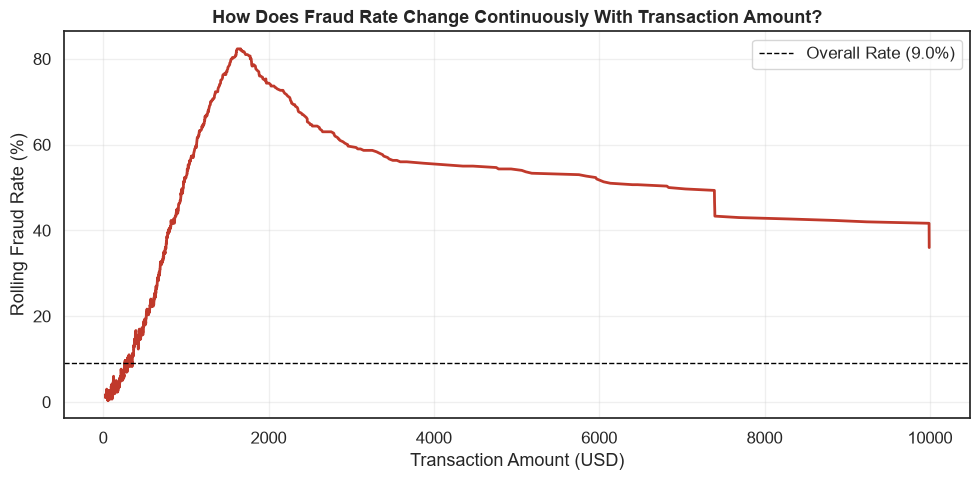

In [137]:
# Sort by amount, then compute a rolling fraud rate across a moving window of transactions
df_sorted = df_cleaned_transaction_data.sort_values("amount_usd").reset_index(drop=True)
df_sorted["rolling_fraud_rate"] = df_sorted["is_fraud"].rolling(window=300, center=True).mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_sorted["amount_usd"], df_sorted["rolling_fraud_rate"], color="#C0392B", linewidth=2)
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
ax.set_title("How Does Fraud Rate Change Continuously With Transaction Amount?")
ax.set_xlabel("Transaction Amount (USD)")
ax.set_ylabel("Rolling Fraud Rate (%)")
#ax.set_xlim(0, 13000)  # zoom into the range where most data sits
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

**Fraud concentrates sharply in the $1K-3K range.** Fraud rate rises steadily from just 1.8% at $0-100 to a striking **72.9%** at $1K-3K, before easing to 22.3% at $3K+. This isn't a simple "bigger = riskier" pattern — fraud peaks in a specific mid-to-high range rather than climbing indefinitely with amount.

The line plot confirms and sharpens the earlier finding: fraud risk begins climbing from as low as **$500**, peaks sharply around **$1,000-1,800** (~83%), and stays elevated afterward with a noticeable dip near **$6,700**. The instability seen beyond $7,000 reflects low transaction volume there, not a real trend.

**Typical fraud amounts are roughly 3.6x higher than legitimate ones.** The median fraudulent transaction sends **$550**, compared to just **$151** for legitimate transactions — a clear, consistent gap that holds up whether viewed as an overall median or broken down by channel.

**Fees follow the same pattern, proportionally.** Fraudulent transactions carry a typical fee of **$9.28** versus **$3.36** for legitimate ones — makes sense given fees scale with amount (recall the earlier finding: fee ≈ 2% of amount)

**The pattern holds across every channel, but ATM stands out.** Median fraud amount is highest on **ATM ($656)**, followed by **web ($586)** and **mobile ($495)** — while legitimate amounts stay flat and low (~$150-156) regardless of channel. This tells you fraud isn't just larger in general — it's disproportionately larger specifically where scrutiny may be lower **(ATM, less identity verification at the point of transaction).**

**Combining amount and channel sharpens the picture further.** The fraud rate heatmap shows the $1K-3K range is dangerous everywhere, but **web transactions in that range hit an 83.4% fraud rate** — the single highest cell in the entire grid — followed by ATM (66.7%) and mobile (57.0%). This is the most actionable finding here: large transactions on **web** specifically deserve the closest scrutiny.

**No clear evidence of deliberate "structuring."** If fraudsters were intentionally keeping amounts just under reporting thresholds ($1,000 or $3,000) to avoid detection, we'd expect visible spikes just below those lines. Instead, the histogram shows a smooth, steadily declining count as amount increases, with no unusual clustering near either threshold — suggesting fraud amounts in this dataset aren't being deliberately engineered to dodge specific limits, at least not in an obvious way.

**Overall takeaway:** amount and fee are strong, consistent fraud signals on their own — fraud transactions typically involve larger sums and higher fees — but the real value comes from combining amount with channel, which reveals that the danger isn't just "large transactions" in the abstract, but specifically **large transactions on web and ATM channels**.

### 8. Bringing It all Together 

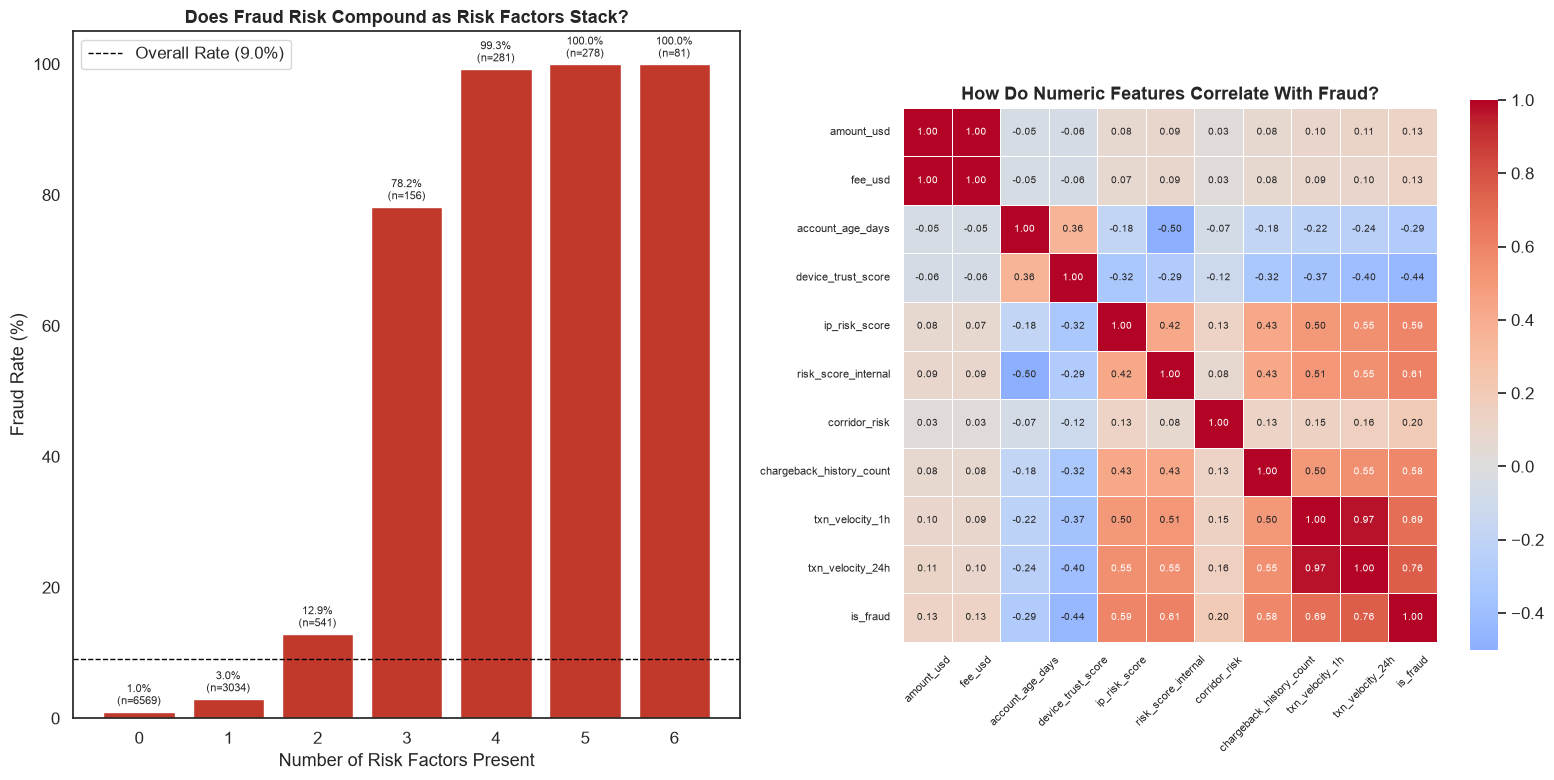

In [142]:
# Build a risk-flag counter using the strongest individual signals found across the EDA
df_cleaned_transaction_data["risk_flag_count"] = (
    df_cleaned_transaction_data["new_device"].astype(int) +
    df_cleaned_transaction_data["location_mismatch"].astype(int) +
    (df_cleaned_transaction_data["chargeback_history_count"] > 0).astype(int) +
    (df_cleaned_transaction_data["account_age_tier"] == "New Account (1-90 days)").astype(int) +
    (df_cleaned_transaction_data["device_trust_tier"] == "Critical Trust (0-0.30)").astype(int) +
    (df_cleaned_transaction_data["kyc_tier"] == "low").astype(int)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes = axes.flatten()

# Q1: When multiple risk factors combine, does fraud rate compound?
risk_stack_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "risk_flag_count").sort_index()
bars = axes[0].bar(risk_stack_fraud.index.astype(str), risk_stack_fraud["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}%\n(n={count})" for rate, count in zip(risk_stack_fraud["fraud_rate_pct"], risk_stack_fraud["count"])]
axes[0].bar_label(bars, labels=labels, padding=3, fontsize=8)
axes[0].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[0].set_title("Does Fraud Risk Compound as Risk Factors Stack?")
axes[0].set_xlabel("Number of Risk Factors Present")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].legend()

# Q2: Correlation heatmap - which numeric features relate most to fraud?
numeric_cols_for_corr = [
    "amount_usd", "fee_usd", "account_age_days", "device_trust_score",
    "ip_risk_score", "risk_score_internal", "corridor_risk",
    "chargeback_history_count", "txn_velocity_1h", "txn_velocity_24h", "is_fraud"
]
full_corr = df_cleaned_transaction_data[numeric_cols_for_corr].corr().round(2)
sns.heatmap(full_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, ax=axes[1], annot_kws={"size": 7},  cbar_kws={"shrink": 0.8})
axes[1].set_title("How Do Numeric Features Correlate With Fraud?")
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)


plt.tight_layout()
plt.show()

**Risk factors compound dramatically.** A transaction with zero risk flags has just a **1.0%** fraud rate, rising only modestly with one or two flags (3.0%, 12.9%). But past **three flags**, risk explodes — jumping to **78.2%**, then **99-100%** with four or more. One warning sign alone means little; three or more happening together is almost a certain sign of fraud. This confirms fraud here isn't driven by any single factor, but by unfamiliarity signals (new device, new account, low trust, location mismatch, chargeback history, low KYC) stacking together.

**The correlation heatmap confirms the strongest individual predictors.** `txn_velocity_24h` (0.76), `txn_velocity_1h` (0.69), `risk_score_internal` (0.61), `ip_risk_score` (0.59), and `chargeback_history_count` (0.58) all show strong positive correlation with fraud, while `device_trust_score` (-0.44) and `account_age_days` (-0.29) correctly show strong *negative* correlation — lower trust and younger accounts mean higher fraud risk, exactly as seen throughout the EDA. Notably, `amount_usd` and `fee_usd` show only a weak linear correlation (0.13) — a reminder that their relationship with fraud is the non-linear, peaked pattern found earlier (spiking around $500 -1,800), not a simple straight-line trend that correlation alone can capture.

**Overall conclusion: across every section of this EDA, one consistent theme emerged — fraud in FinLora's data is overwhelmingly associated with **unfamiliar signals**: new accounts, new devices, low trust scores, location mismatches, and — as this final section shows — these signals compound powerfully when combined. This gives strong, well-evidenced direction for feature engineering: combined/interaction features (e.g., a single "unfamiliarity score") are likely to be highly predictive going into modelling**.

### Saving the dataset for Feature Engineering and selection

In [143]:
df_cleaned_transaction_data.to_parquet(r"C:\Users\leest\OneDrive\Data Projects\Amdari Projects\Digital_Transfer_Fraud_Detection_System\Datasets\Artifats\FE_dataset")

### Next Steps

This concludes the exploratory data analysis. The next phase of the project moves into **feature engineering and selection**, where the patterns uncovered here will be translated into model-ready features.

This work will continue in a new notebook: **`FeatureEngineering.ipynb`**.